In [1]:
from __future__ import division
import json
%matplotlib inline
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
import itertools, operator
import csv
import os,glob
import datetime
import geopandas as gpd
from shapely import wkt
from scipy.stats import linregress, spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LogNorm
import math
import matplotlib.patches as mpatches
import matplotlib as mpl

import os, pandas as pd, geopandas as gpd
from shapely import wkt
from IPython.display import display

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, box

import osmnx as ox

import networkx as nx
import collections

from scipy.stats import gaussian_kde

from scipy.spatial import cKDTree

from IPython.display import display

import os
import sys

# INFORMATION

In [2]:
dates = ['_07_2022','_08_2022','_07_2023','_08_2023'] 

In [3]:
DATE = '07_08_2022_2023'

# COLORS

In [5]:
colors_income = ['#FCBF49','#F77F00','#D62828'] #low, medium, high
colors_gender = ['#7209B7','#4CC9F0'] #fem, mal
colors_age = ['#BE95C4','#9F86C0','#5E548E','#231942'] #young->old

In [6]:
from matplotlib.colors import LinearSegmentedColormap
cmap_income = LinearSegmentedColormap.from_list('income', colors_income)
cmap_gender = LinearSegmentedColormap.from_list('gender', colors_gender)
cmap_age = LinearSegmentedColormap.from_list('age', colors_age)

# CITIES

In [7]:
cities = ['Madrid', 'Barcelona', 'Valencia', 'Zaragoza', 'Sevilla', 'Malaga', 'Murcia', 'Palma_de_Mallorca', 'Las_Palmas',
          'Alicante', 'Bilbao', 'Valladolid', 'Cordoba', 'Vigo', 'Gijon', 'Vitoria_Gasteiz', 'A_Coruna', 'Granada', 'Elche', 
          'Cartagena', 'Oviedo', 'Jerez_de_la_Frontera', 'Santa_Cruz_de_Tenerife']

In [8]:
len(cities)

23

# OPEN DISTRICTS DATA

In [9]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2\dataframes')

gdfs = []
for d in dates:
    df = pd.read_csv(f'results_districts{d}.csv')

    # 2.2 convierte geometry (WKT → shapely)
    if df['geometry'].dtype == object:
        df['geometry'] = df['geometry'].apply(wkt.loads)

    gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:25830')
    gdfs.append(gdf)

    print(f'\n── District results {d} ─────────────────────────────')
    display(gdf[['city','ID','avg_T']].head())

results_districts = pd.concat(gdfs, ignore_index=True)

num_cols   = [c for c in results_districts.select_dtypes('number').columns
              if c not in ['x', 'y']]                # x,y se recalcularán
group_cols = ['city', 'ID']

results_districts = (results_districts
                     .groupby(group_cols, as_index=False)
                     .agg({**{c: 'mean' for c in num_cols},
                           'geometry': 'first'}))

results_districts = gpd.GeoDataFrame(results_districts,
                                     geometry='geometry',
                                     crs='EPSG:25830')

cent = results_districts.geometry.centroid
results_districts['x'] = cent.x
results_districts['y'] = cent.y

results_districts = {c: g.copy() for c, g in results_districts.groupby('city')}


── Valores distritales _07_2022 ─────────────────────────────


,city,ID,avg_T
0,Vitoria_Gasteiz,01001,37.789074
1,Bilbao,01002,36.407897
2,Bilbao,01004_AM,31.719118
3,Vitoria_Gasteiz,01009_AM,36.294266
4,Vitoria_Gasteiz,01017_AM,34.923216



── Valores distritales _08_2022 ─────────────────────────────


,city,ID,avg_T
0,Vitoria_Gasteiz,01001,37.228333
1,Bilbao,01002,34.345701
2,Bilbao,01004_AM,28.830882
3,Vitoria_Gasteiz,01009_AM,35.204281
4,Vitoria_Gasteiz,01017_AM,33.107865



── Valores distritales _07_2023 ─────────────────────────────


,city,ID,avg_T
0,Vitoria_Gasteiz,01001,32.397593
1,Bilbao,01002,28.571729
2,Bilbao,01004_AM,26.368529
3,Vitoria_Gasteiz,01009_AM,29.919755
4,Vitoria_Gasteiz,01017_AM,28.463876



── Valores distritales _08_2023 ─────────────────────────────


,city,ID,avg_T
0,Vitoria_Gasteiz,01001,36.241111
1,Bilbao,01002,32.248785
2,Bilbao,01004_AM,27.704118
3,Vitoria_Gasteiz,01009_AM,33.954817
4,Vitoria_Gasteiz,01017_AM,31.933235


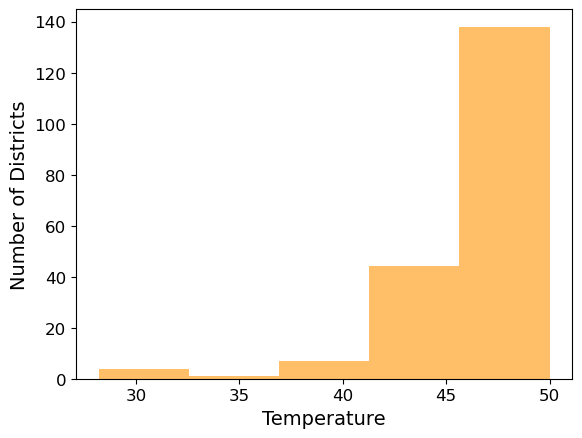

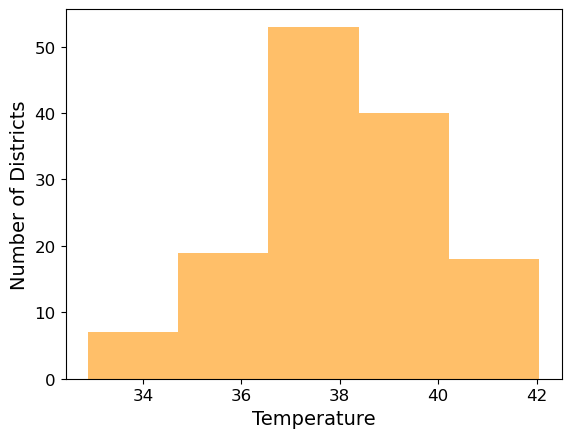

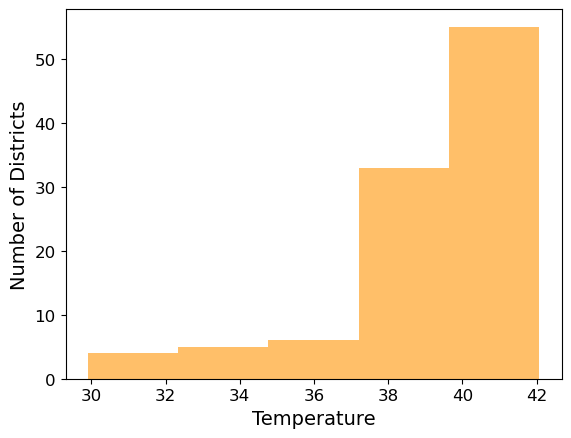

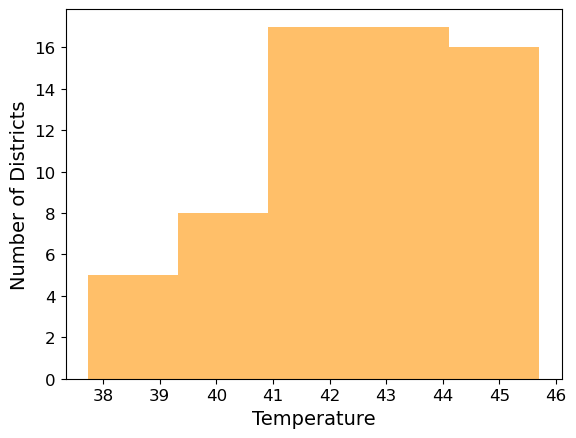

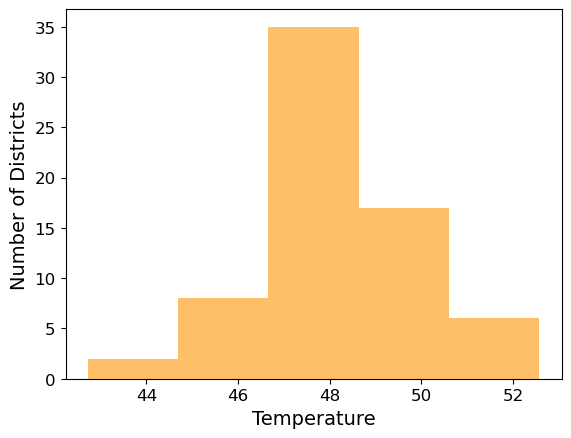

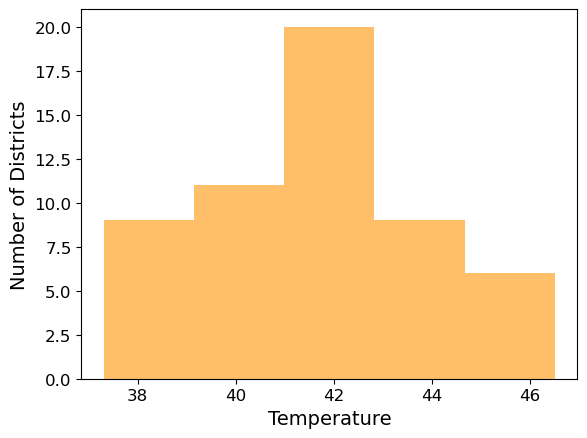

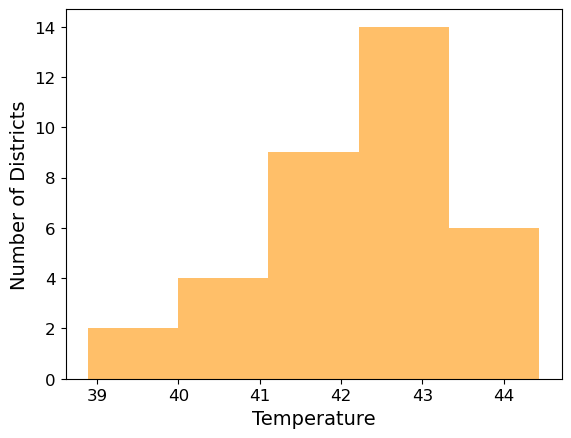

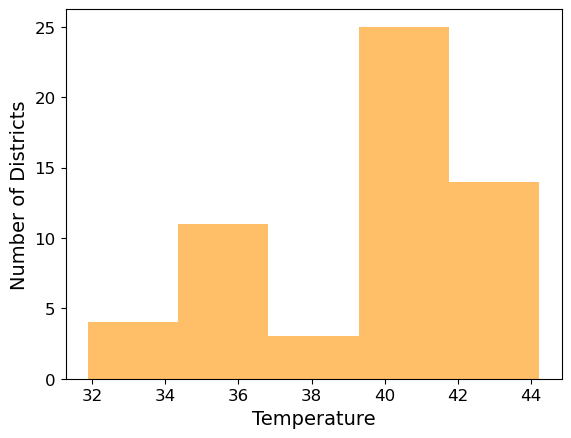

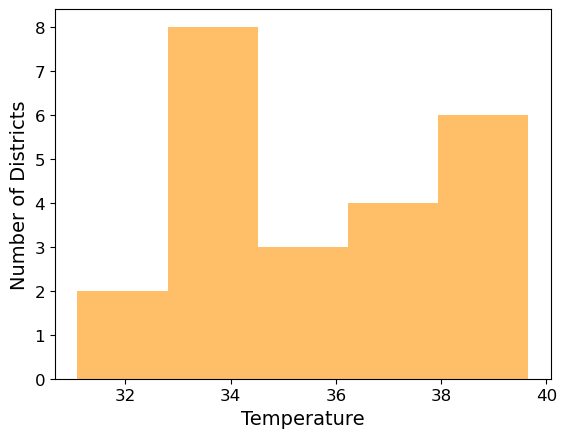

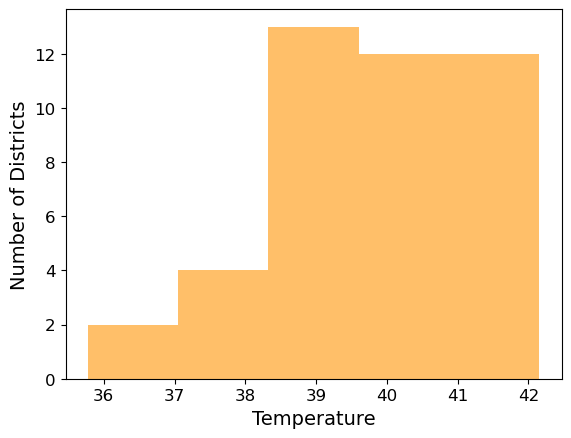

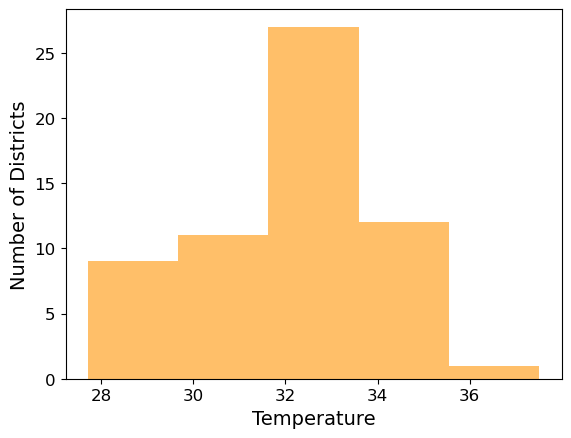

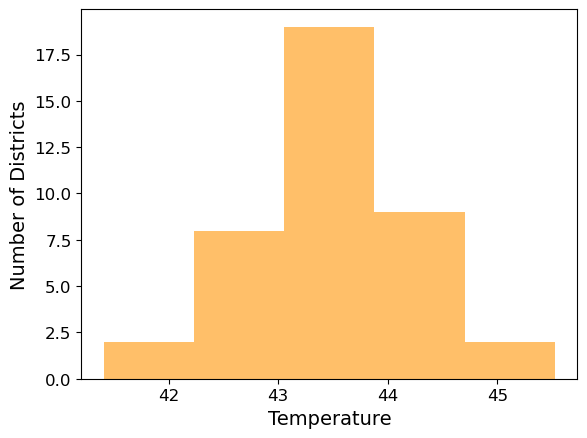

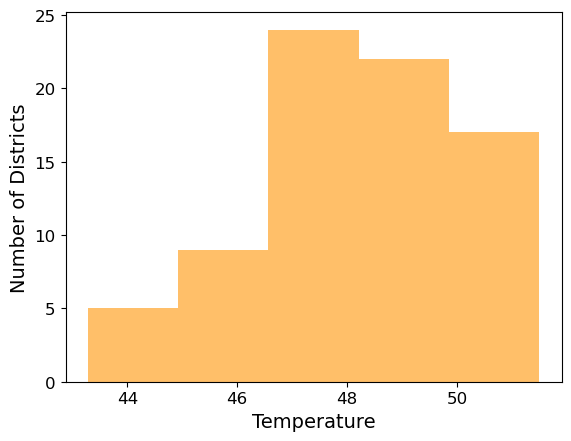

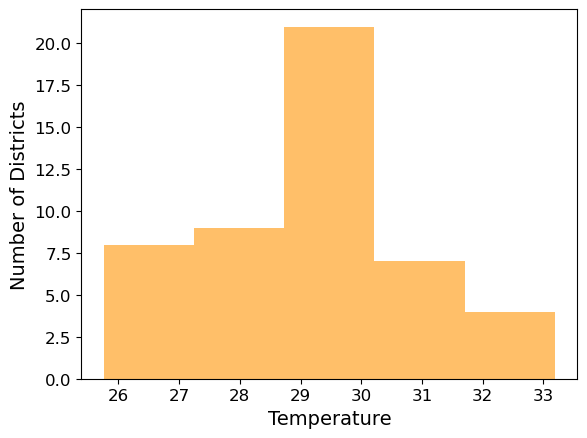

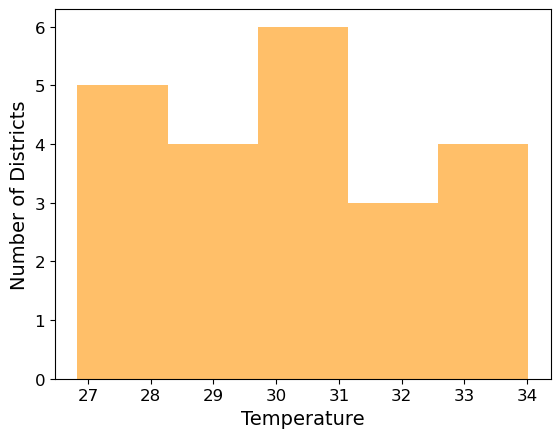

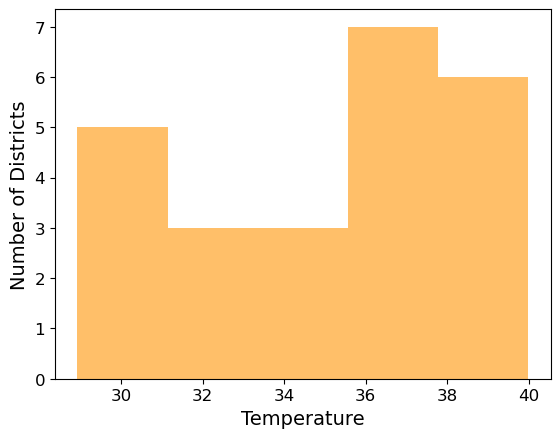

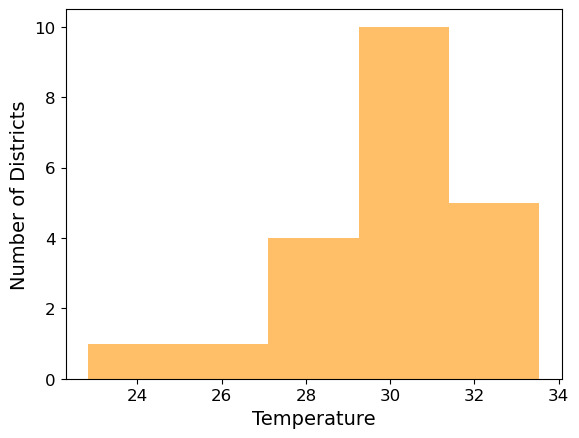

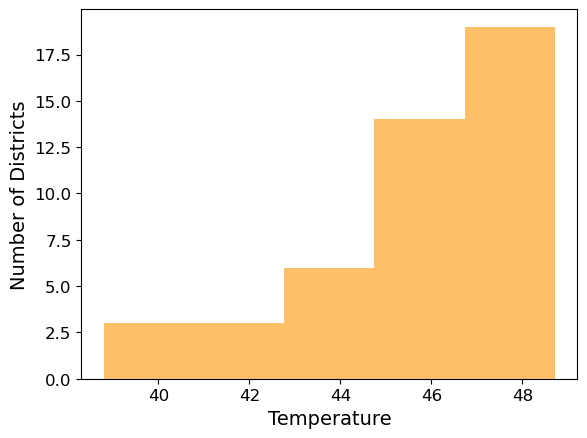

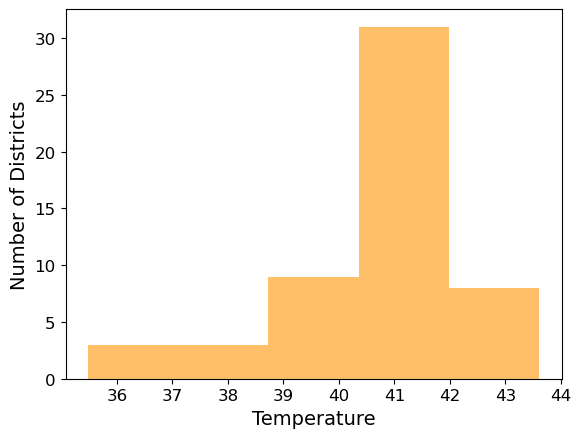

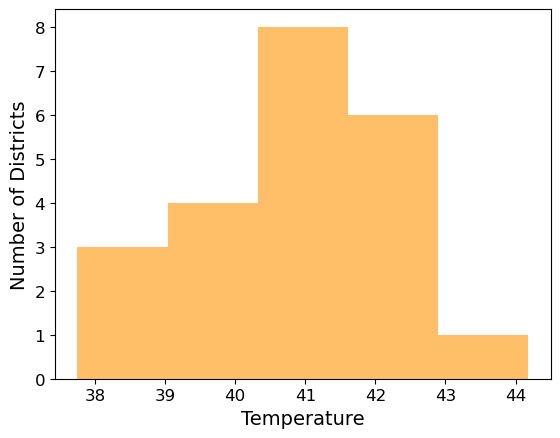

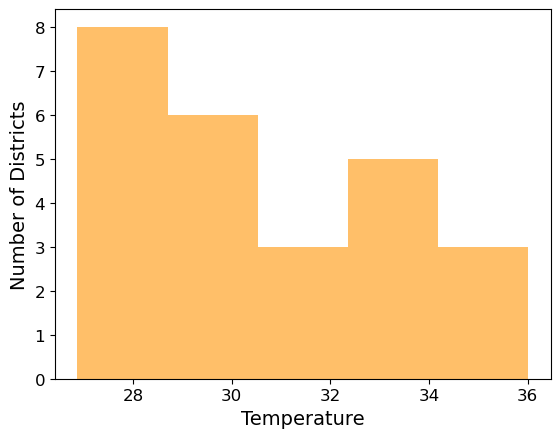

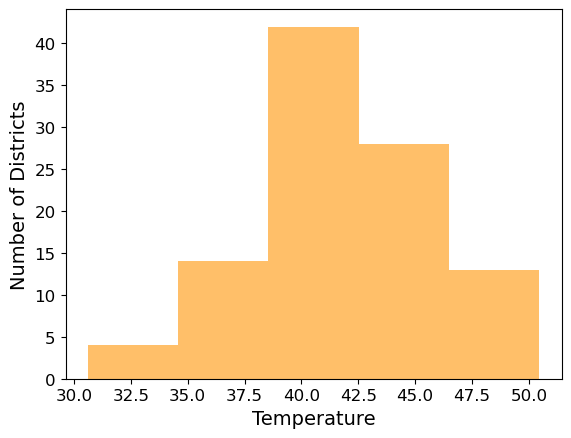

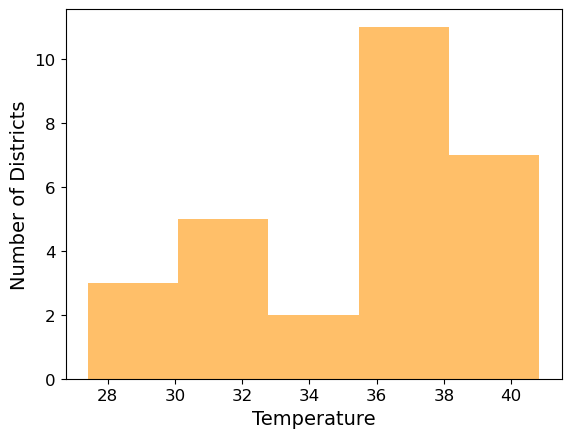

In [10]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2')

for city in cities:
    df_city = results_districts[city]
    
    plt.hist(df_city['avg_T'], bins=5, color='#ffbf69')
    plt.xlabel("Temperature", fontsize=14)
    plt.ylabel("Number of Districts", fontsize=14)
    plt.tick_params(axis='x', labelsize=12) 
    plt.tick_params(axis='y', labelsize=12) 
    plt.show()

# DEFINE DOMAIN

In [11]:
cities_box = {
    'Madrid': "Madrid, Spain",
    'Barcelona': "Barcelona, Spain",
    'Zaragoza': "Zaragoza, Spain",
    'Bilbao': "Bilbao, Spain",
    'Sevilla': "Seville, Spain",
    'Valencia': "Valencia, Spain",
    'Valladolid': "Valladolid, Spain",
    'Cordoba': "Córdoba, Spain",
    'Murcia': "Murcia, Spain",
    'Malaga': "Málaga, Spain",
    'Palma_de_Mallorca': "Palma de Mallorca, Spain",
    'Alicante': "Alicante, Spain",
    'Vigo': "Vigo, Spain",
    'Gijon': "Gijón, Spain",
    'Oviedo': "Oviedo, Spain",
    'Granada': "Granada, Spain",
    'Cartagena': "Cartagena, Spain",
    'A_Coruna': "A Coruña, Spain",
    'Tarragona': "Tarragona, Spain",
    'Pamplona': "Pamplona, Spain",
    'Castellon_de_la_Plana': "Castellón de la Plana, Spain",
    'Santander': "Santander, Spain",
    'Elche': "Elche, Spain",
    'San_Sebastian': "San Sebastián, Spain",
    'Vitoria_Gasteiz': "Vitoria-Gasteiz, Spain",
    'Huelva': "Huelva, Spain",
    'Almeria': "Almería, Spain",
    'Salamanca': "Salamanca, Spain",
    'Lleida': "Lleida, Spain",
    'Jerez_de_la_Frontera': "Jerez de la Frontera, Spain",
    'Albacete': "Albacete, Spain",
    'Burgos': "Burgos, Spain",
    'Logroño': "Logroño, Spain",
    'Badajoz': "Badajoz, Spain",
    'Teruel': "Teruel, Spain",
    'Las_Palmas': "Las Palmas de Gran Canaria, Spain",
    'Santa_Cruz_de_Tenerife': "Santa Cruz de Tenerife, Spain",
    'Palencia': "Palencia, Spain"
}
    

xmin, xmax, ymin, ymax = {}, {}, {}, {}
extended_bbox_dict = {}

for city_key, city_full in cities_box.items():
    try:
        gdf = ox.geocode_to_gdf(city_full)
        poly = gdf.geometry.iloc[0]
        
        metr = gdf.to_crs(epsg=32630)
        metr_poly = metr.geometry.iloc[0]
        
        area_km2 = metr_poly.area / 1e6
        
        # multiply by a “buffer factor”
        buffer_factor = 1.1  
        radius_km = math.sqrt(area_km2 / math.pi) * buffer_factor
        
        centroid = poly.centroid
        dlat = radius_km / 111.32
        dlon = radius_km / (111.32 * math.cos(math.radians(centroid.y)))
        
        minx, miny, maxx, maxy = poly.bounds
        xmin[city_key] = minx - dlon
        xmax[city_key] = maxx + dlon
        ymin[city_key] = miny - dlat
        ymax[city_key] = maxy + dlat
        
        ext = box(xmin[city_key], ymin[city_key], xmax[city_key], ymax[city_key])
        extended_bbox_dict[city_key] = ext
        
    except Exception as e:
        print(f"Error with {city_full}: {e}")

Processing Madrid…


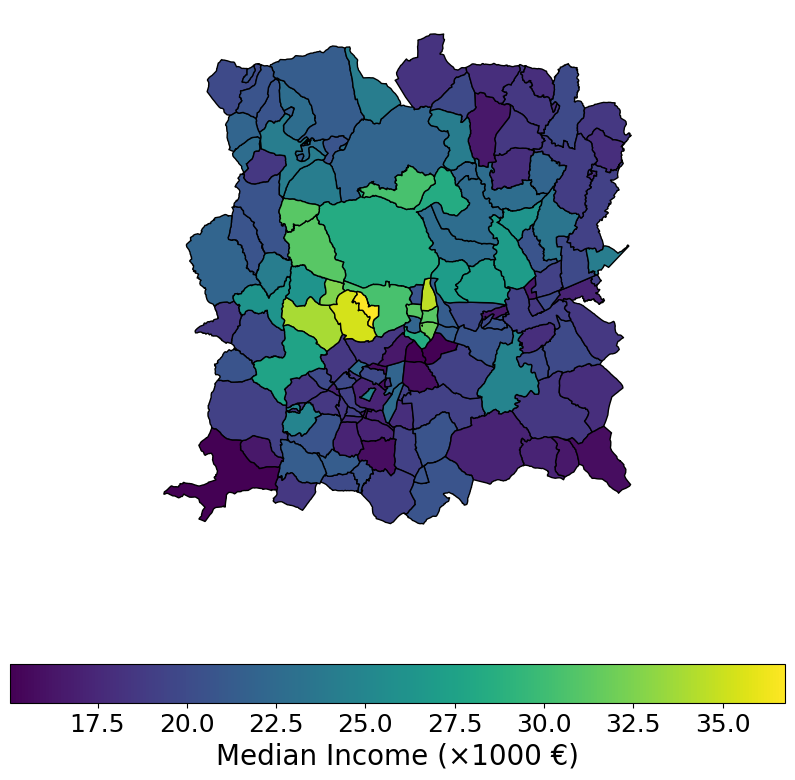

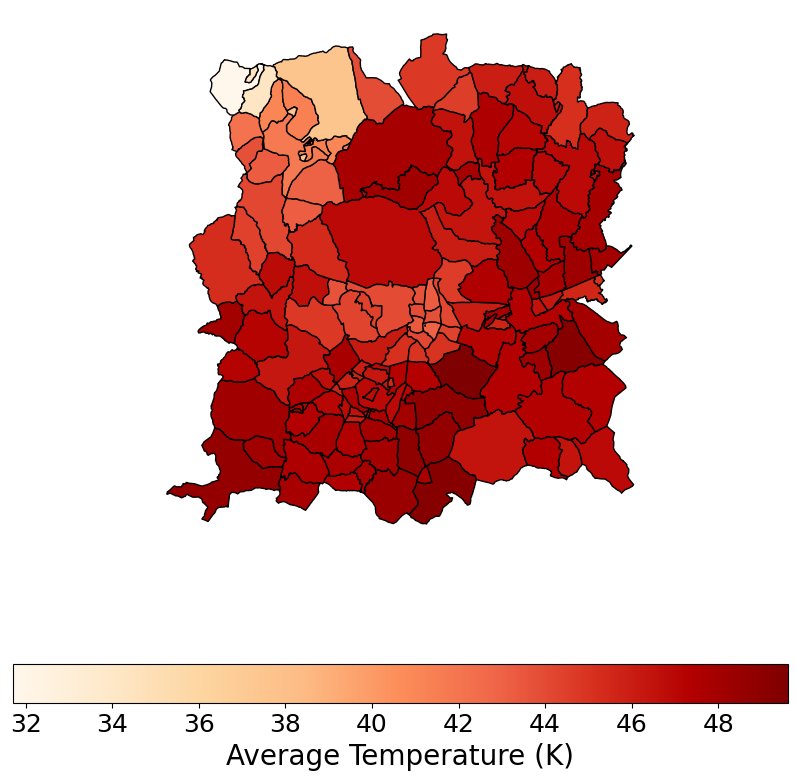

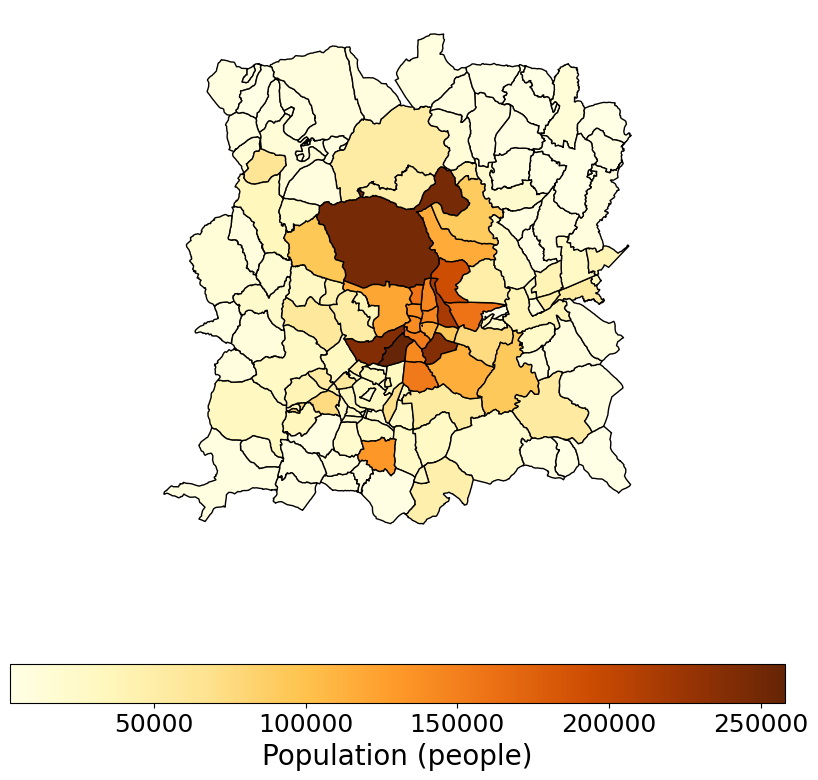

Processing Barcelona…


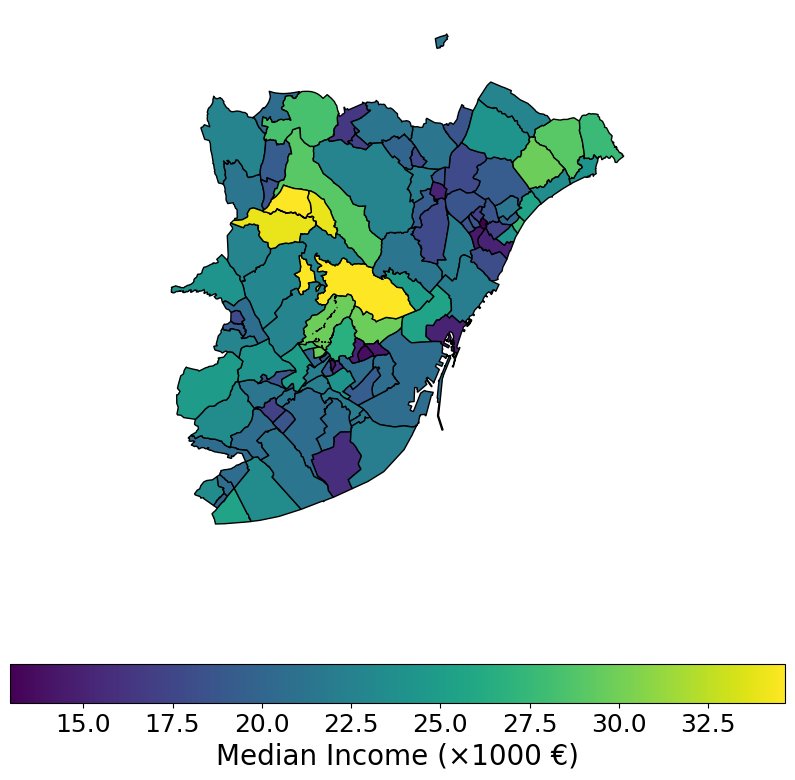

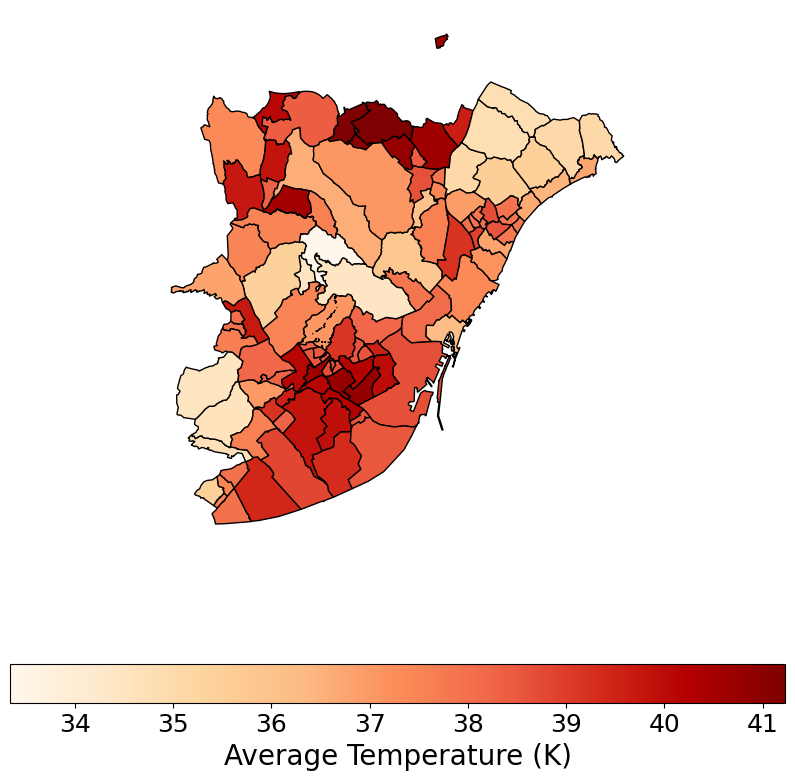

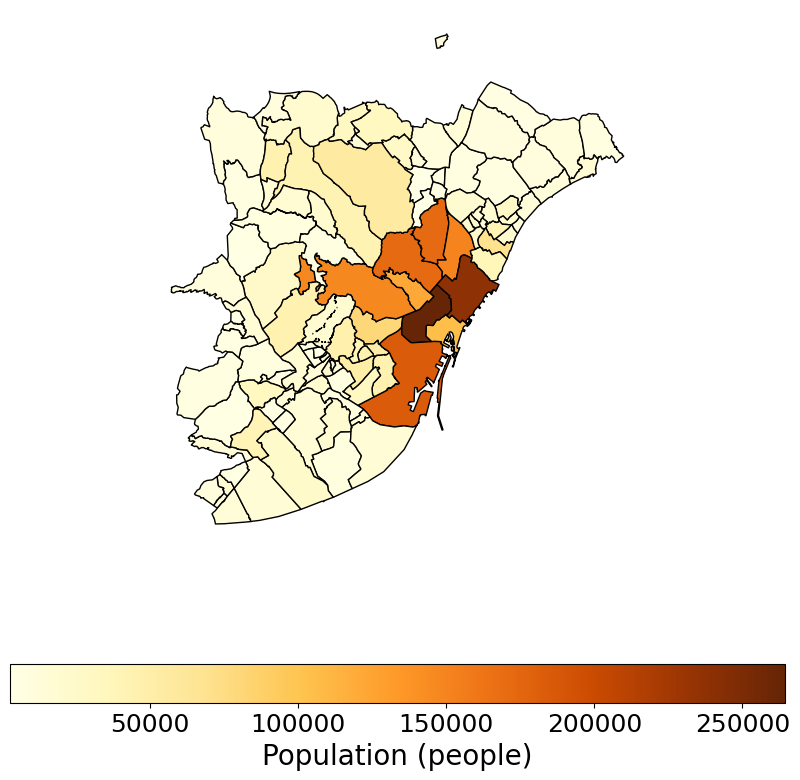

Processing Valencia…


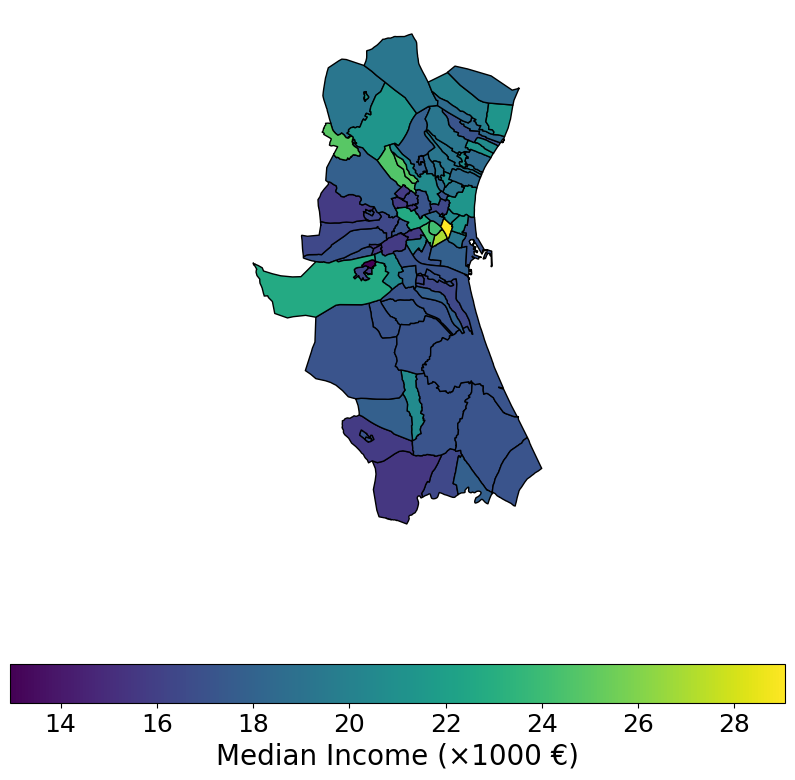

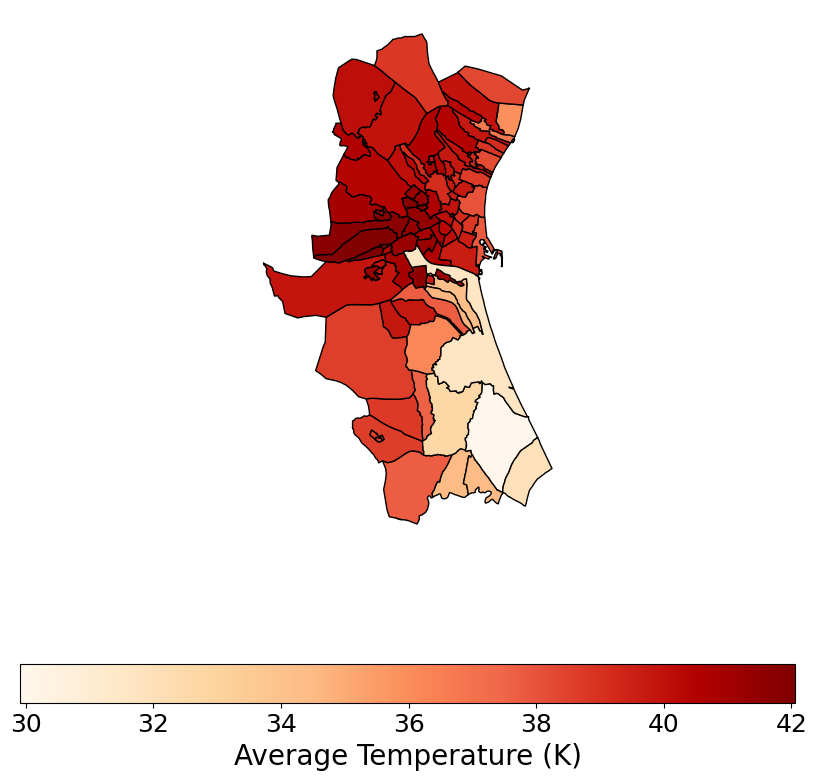

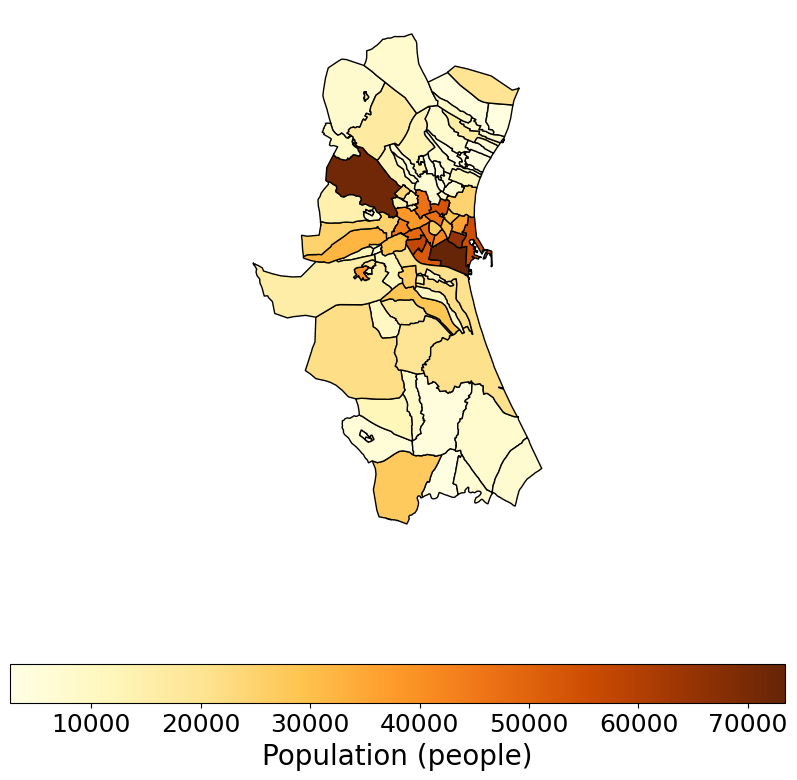

Processing Zaragoza…


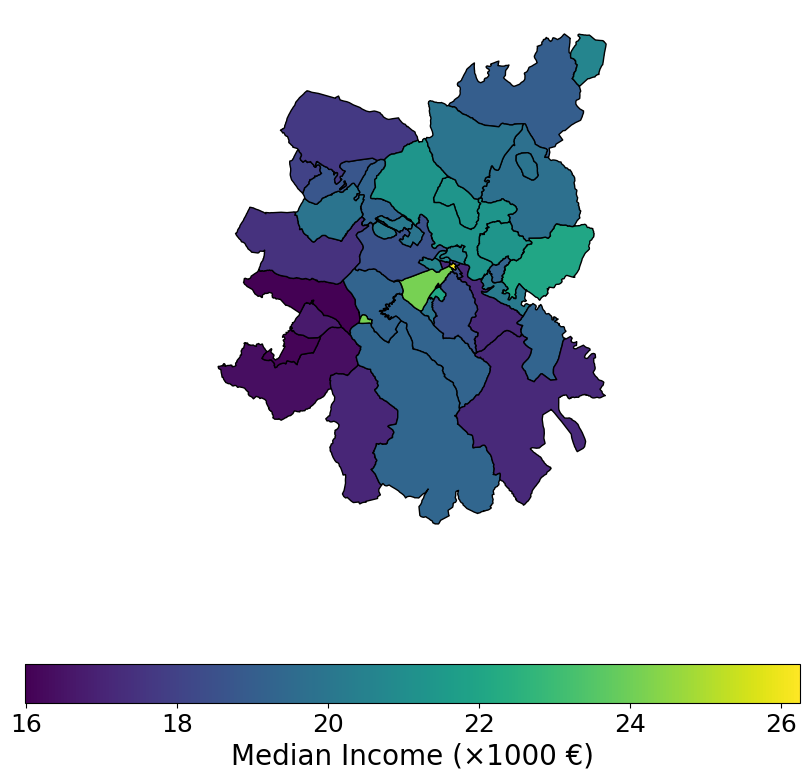

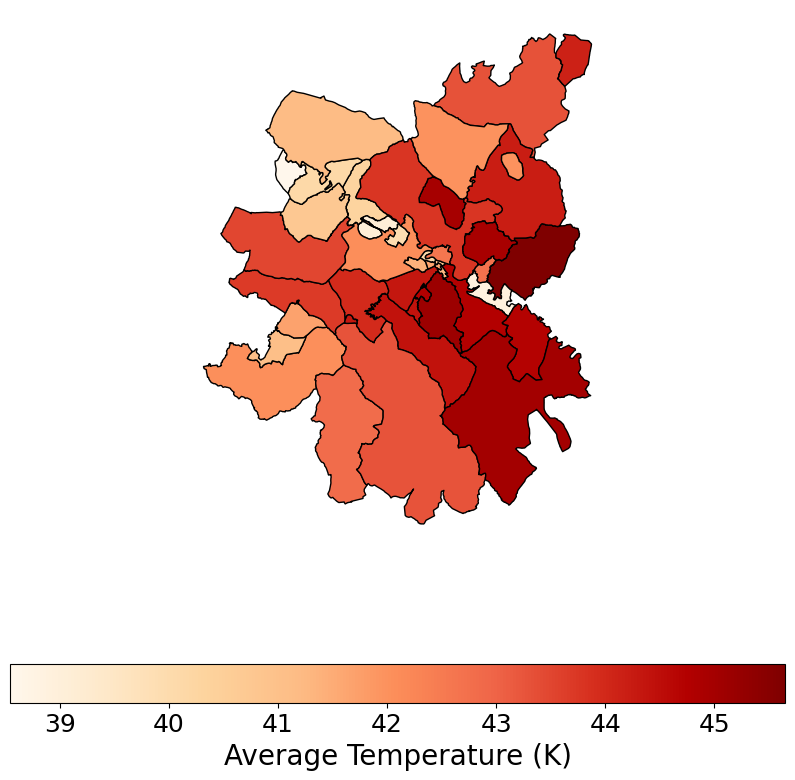

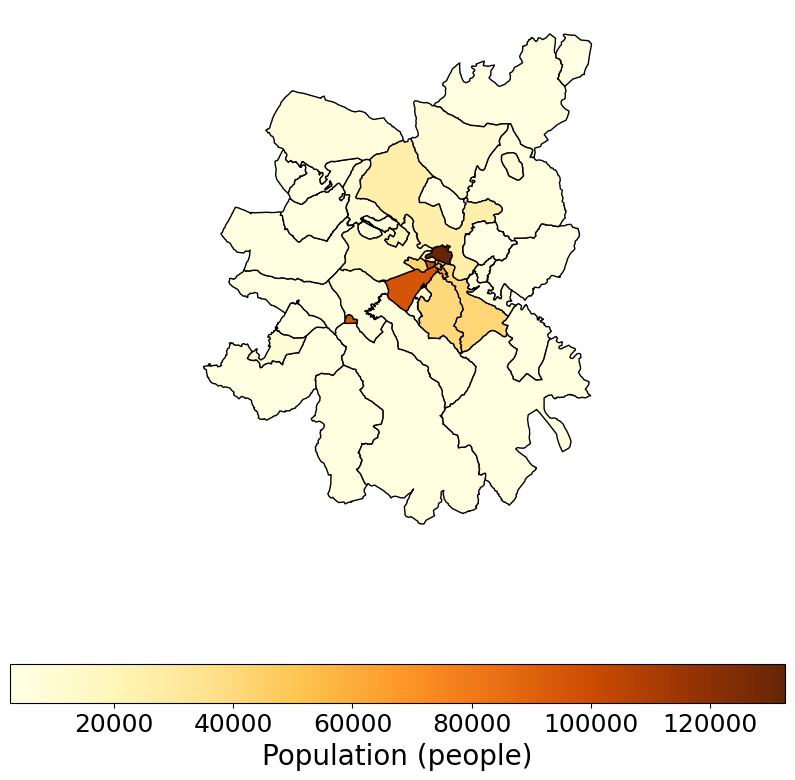

Processing Sevilla…


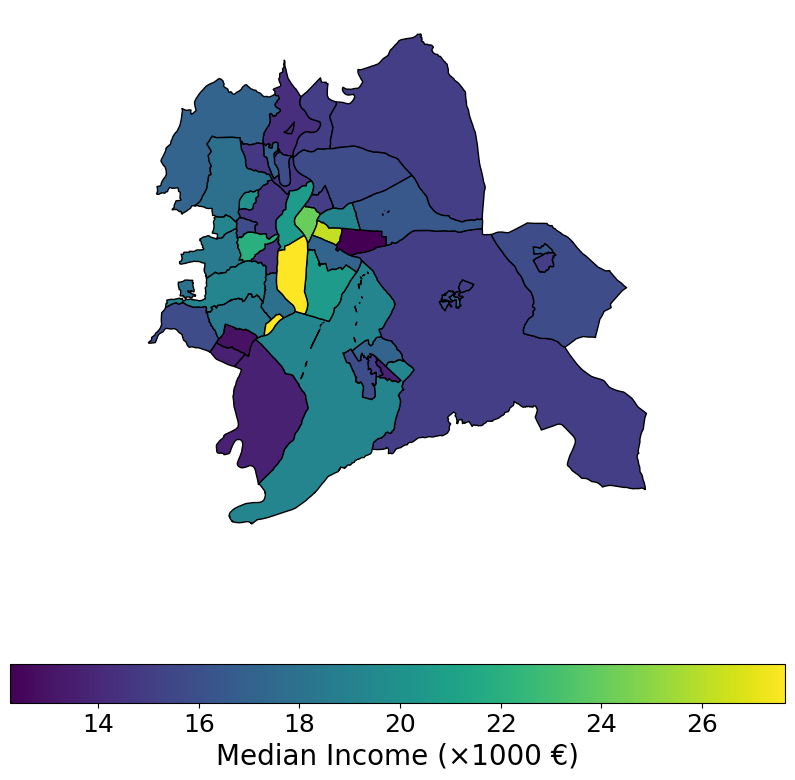

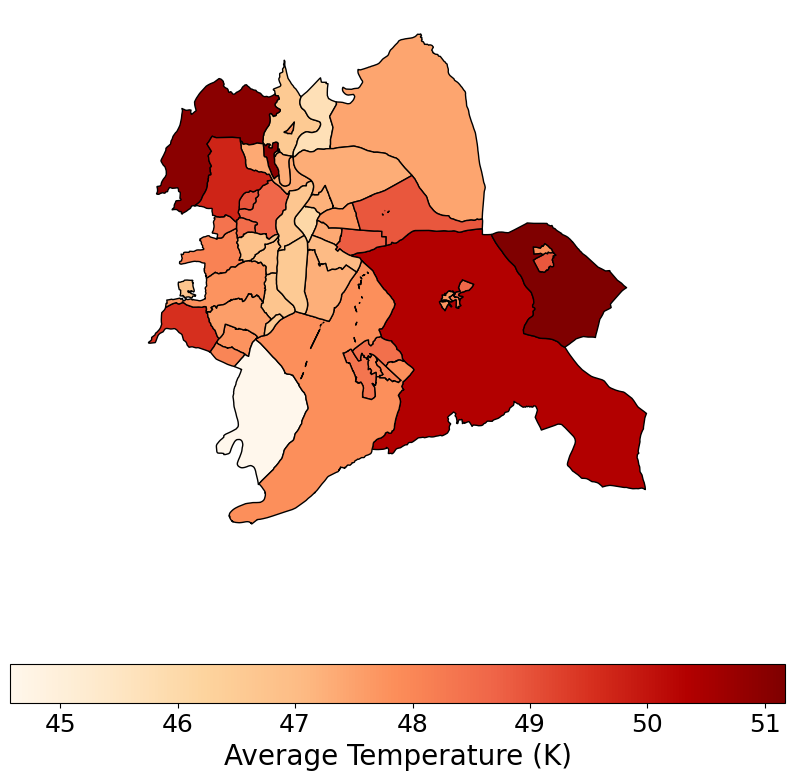

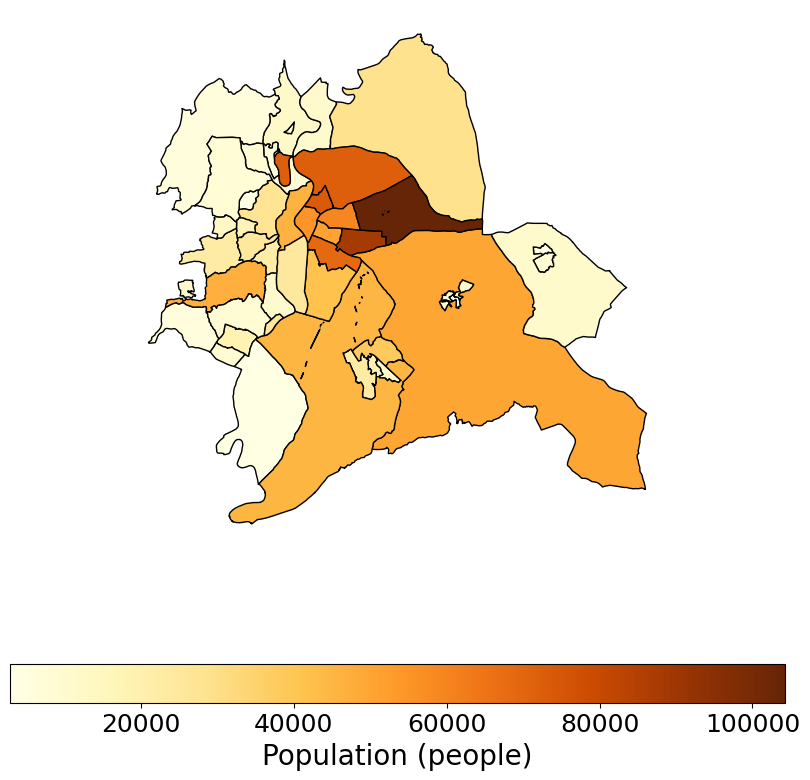

Processing Malaga…


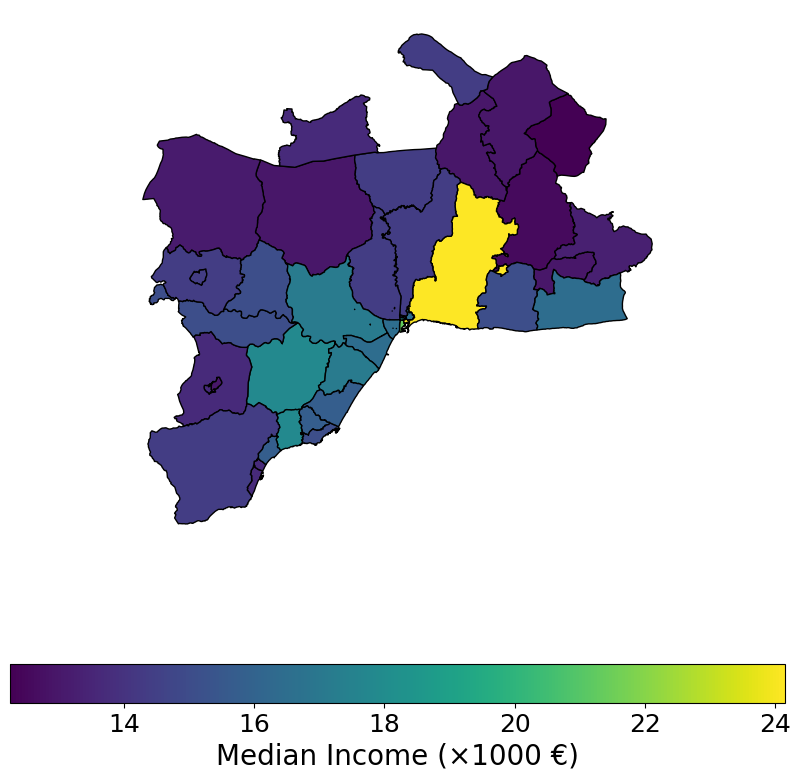

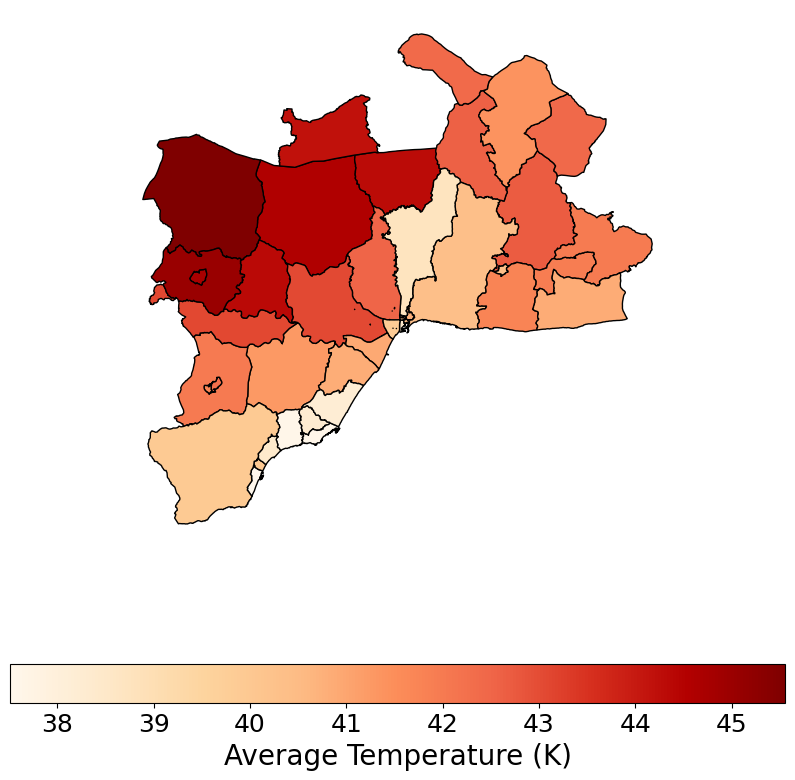

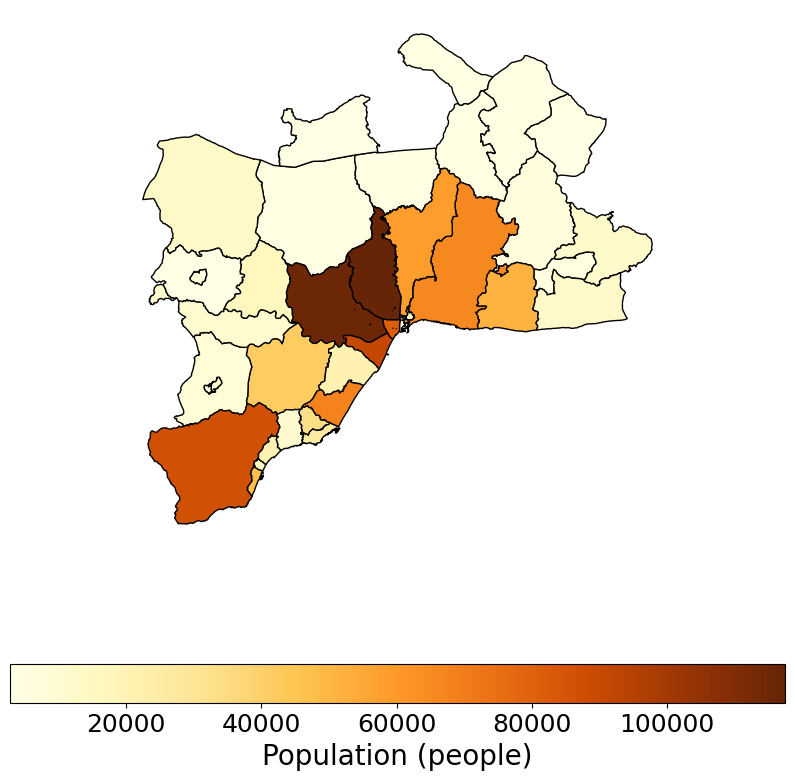

Processing Murcia…


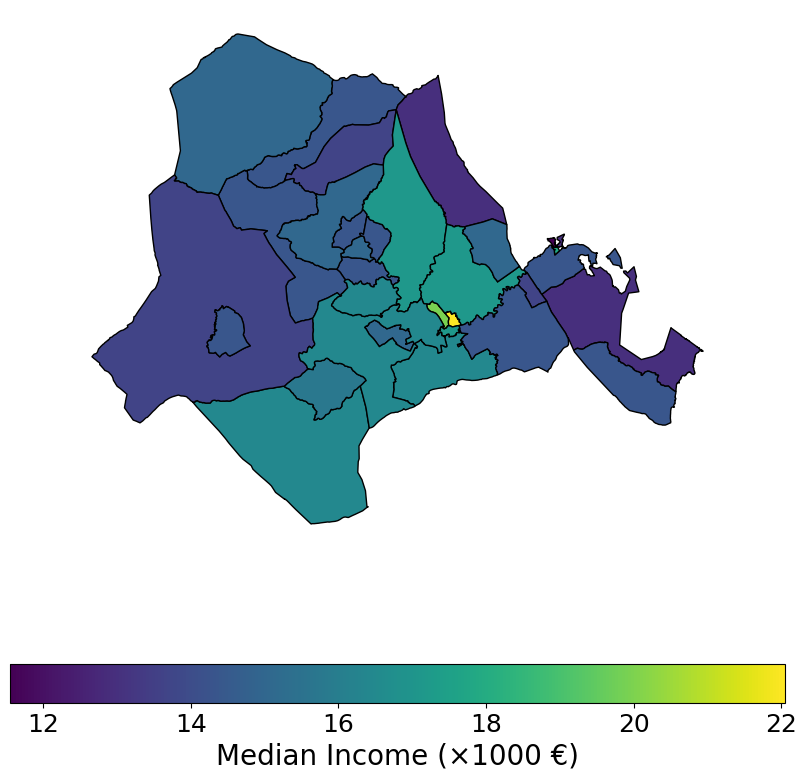

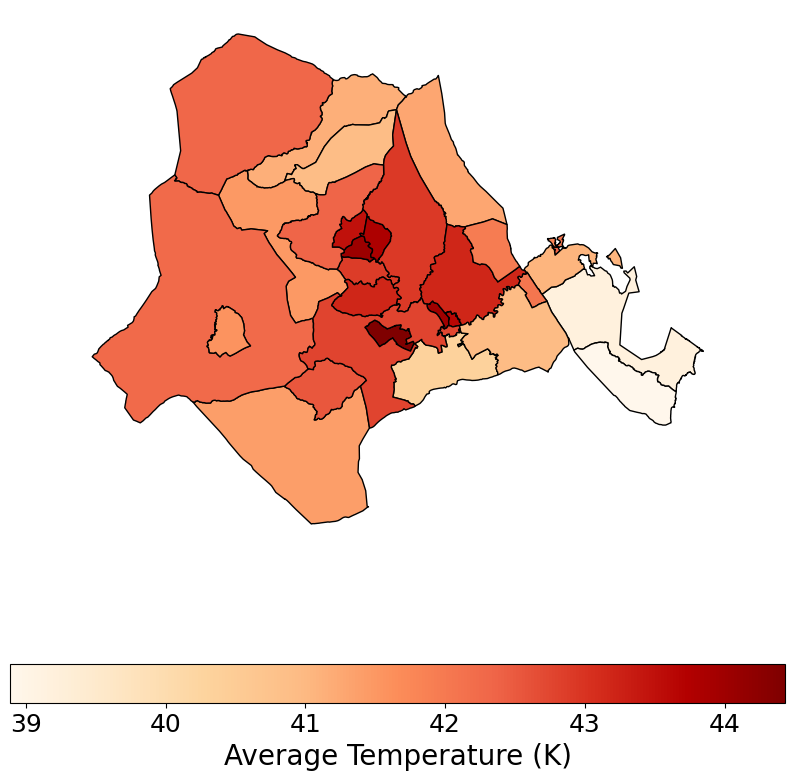

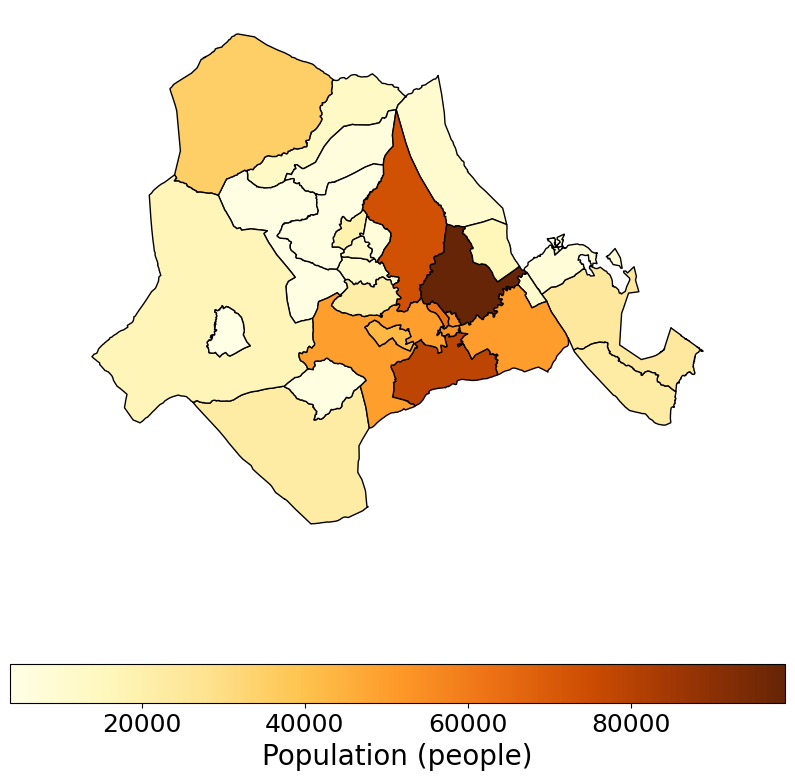

Processing Palma_de_Mallorca…


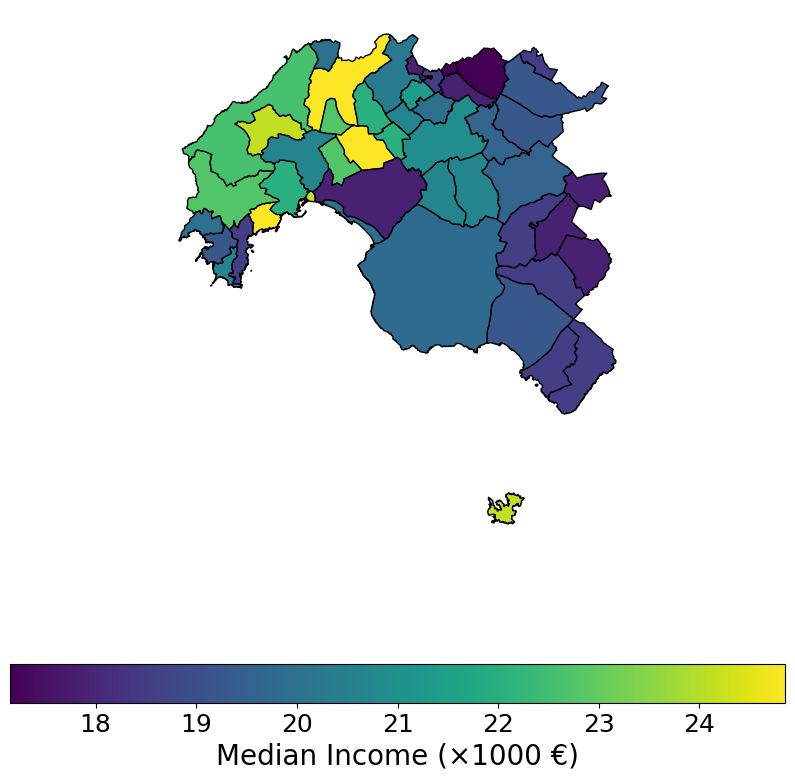

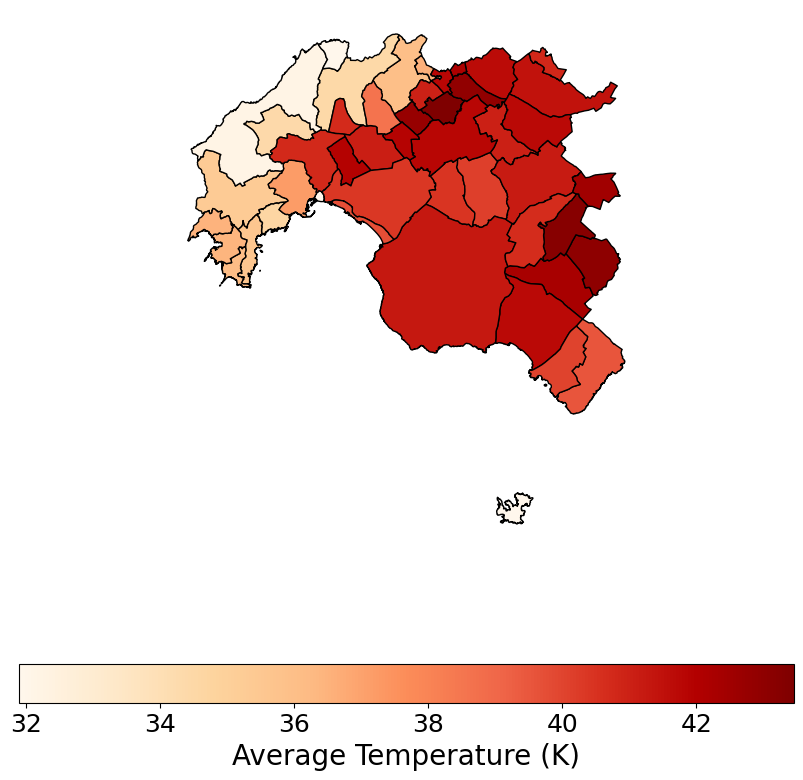

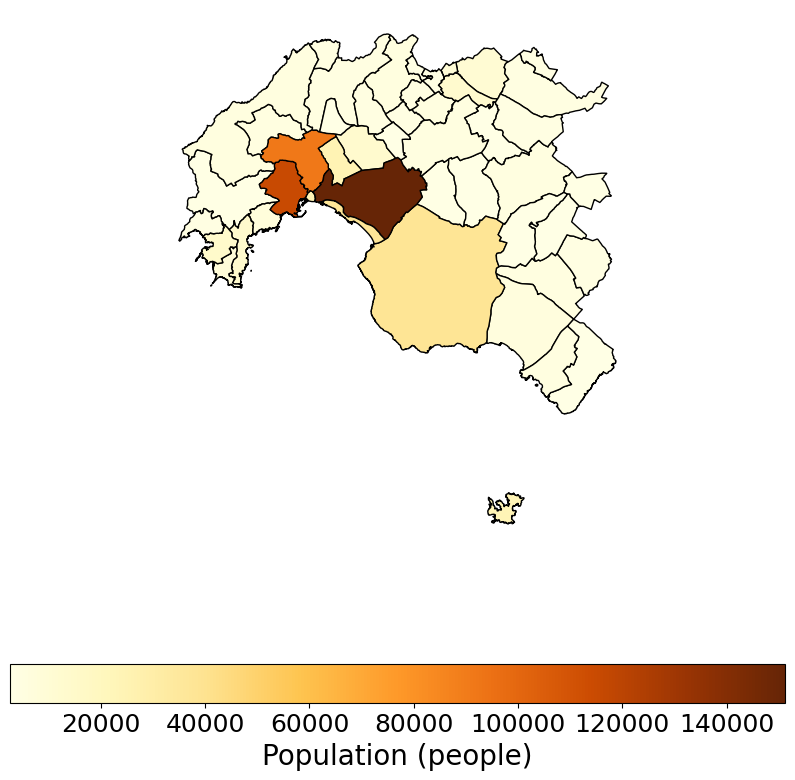

Processing Las_Palmas…


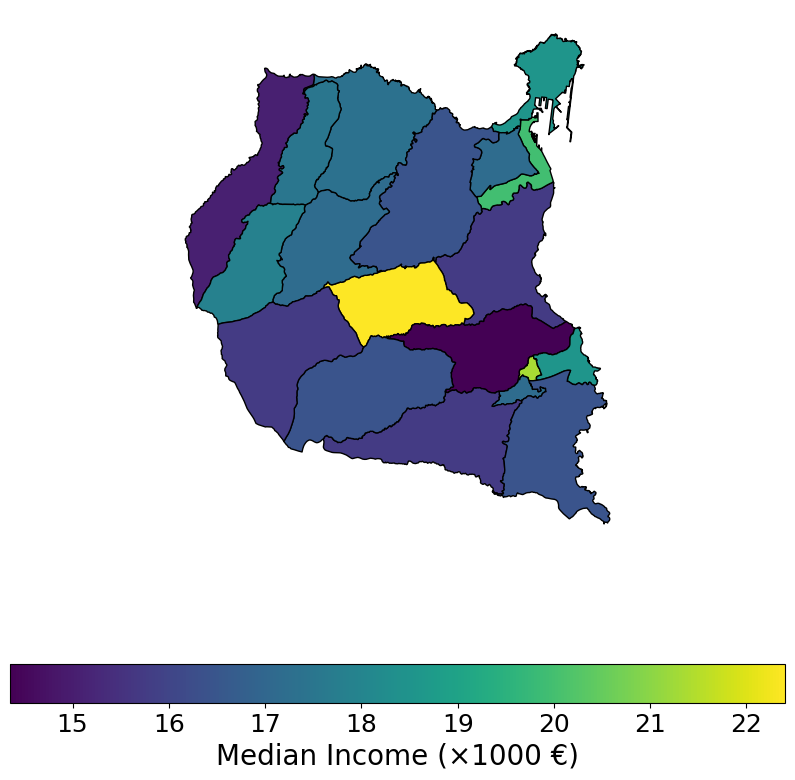

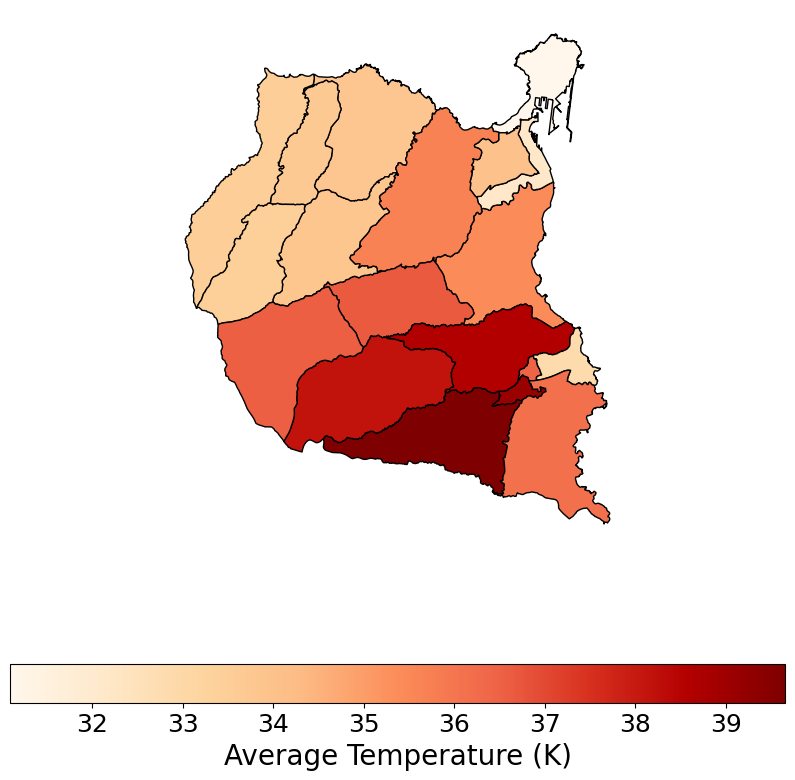

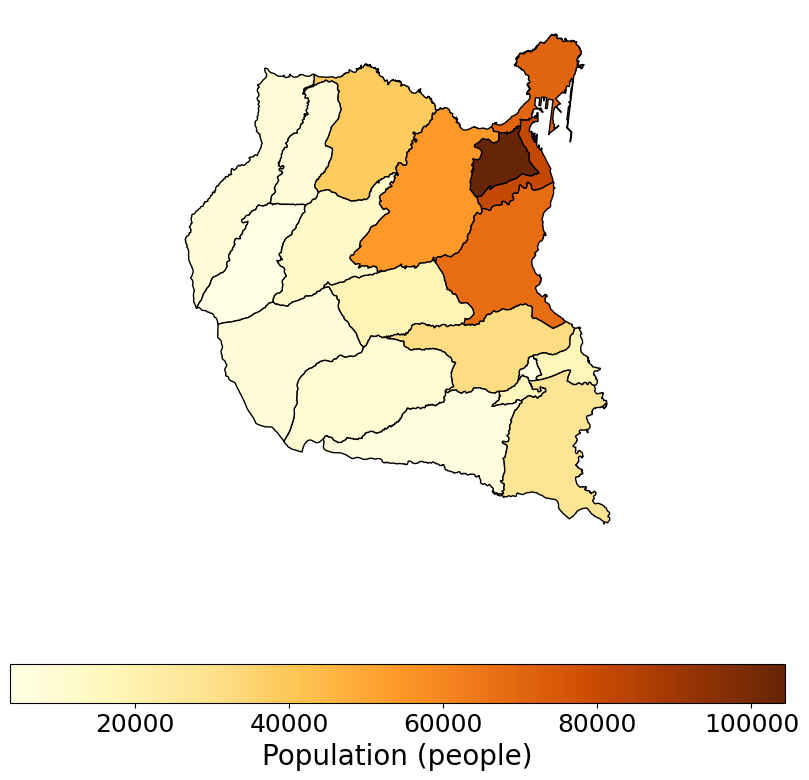

Processing Alicante…


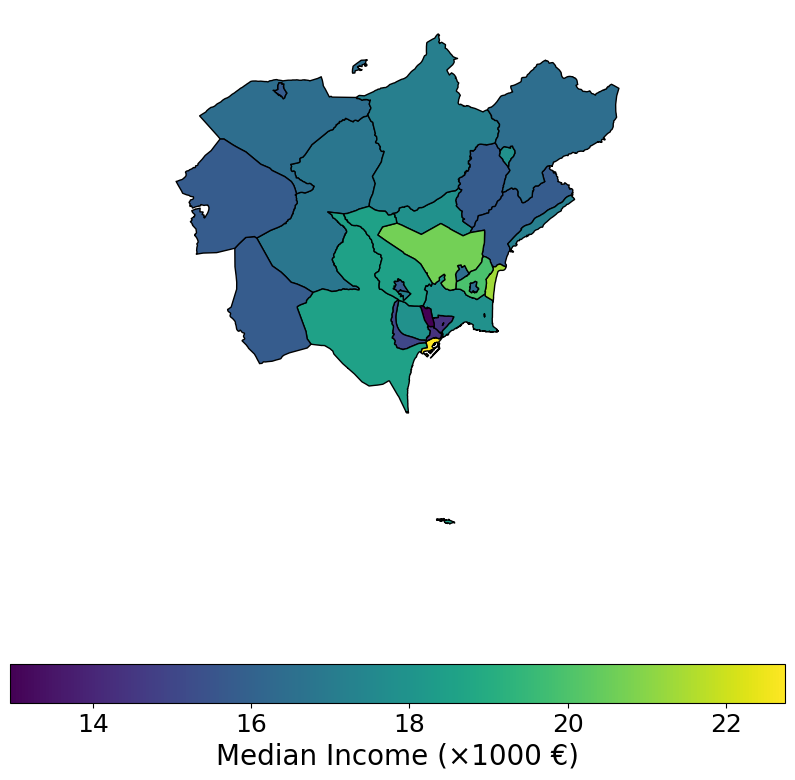

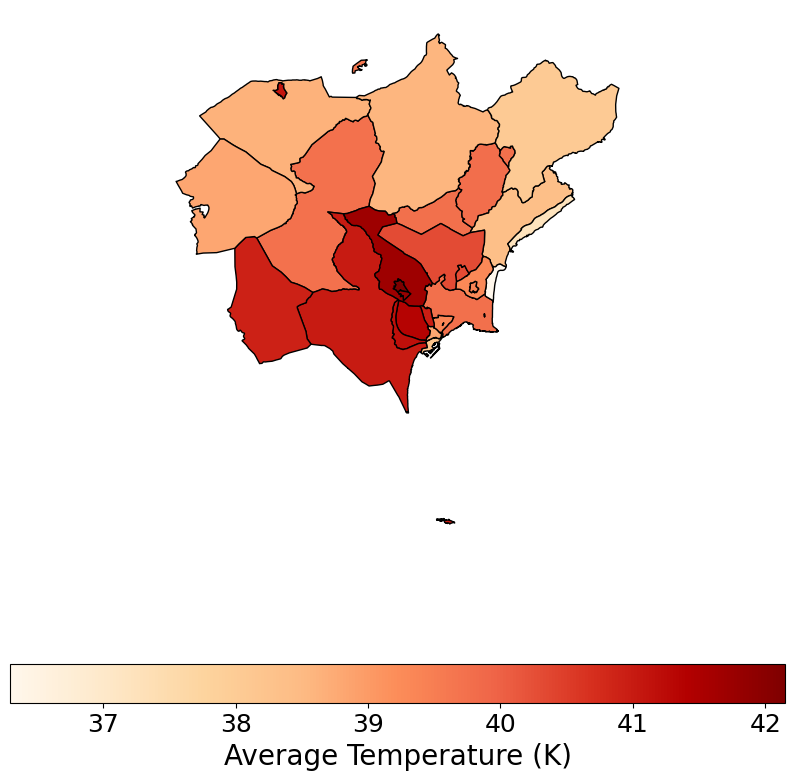

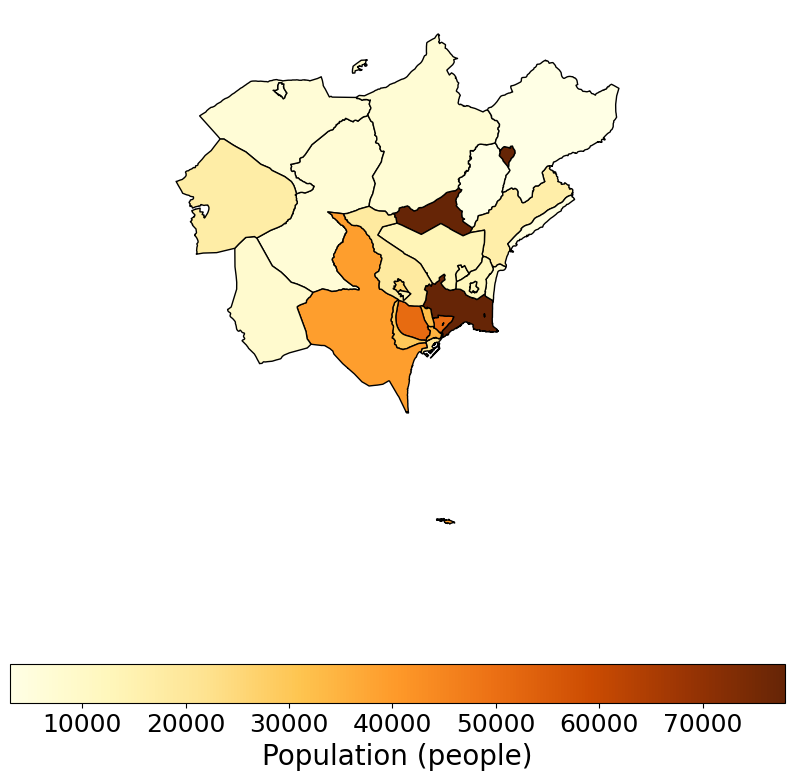

Processing Bilbao…


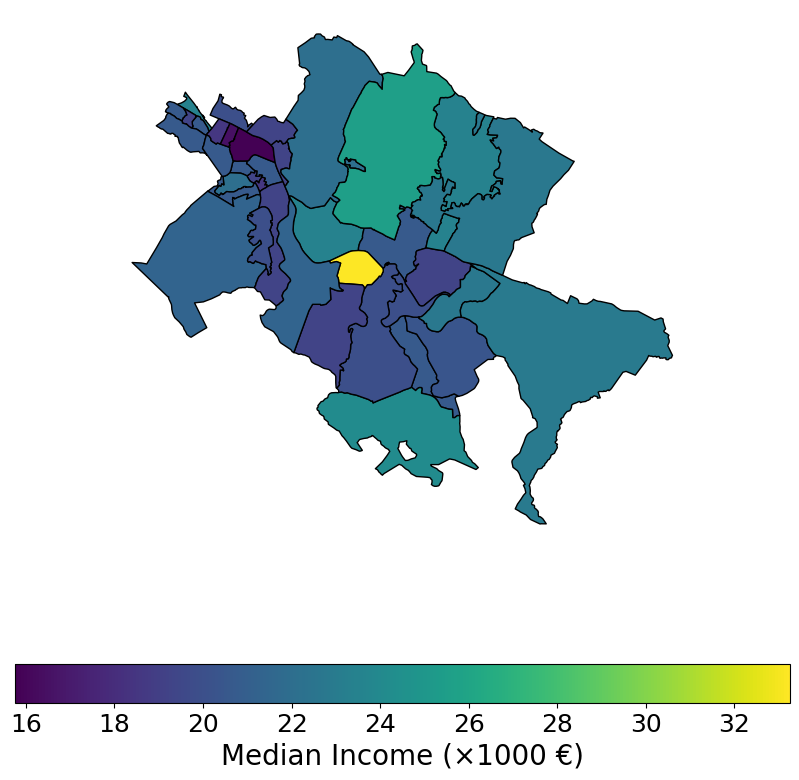

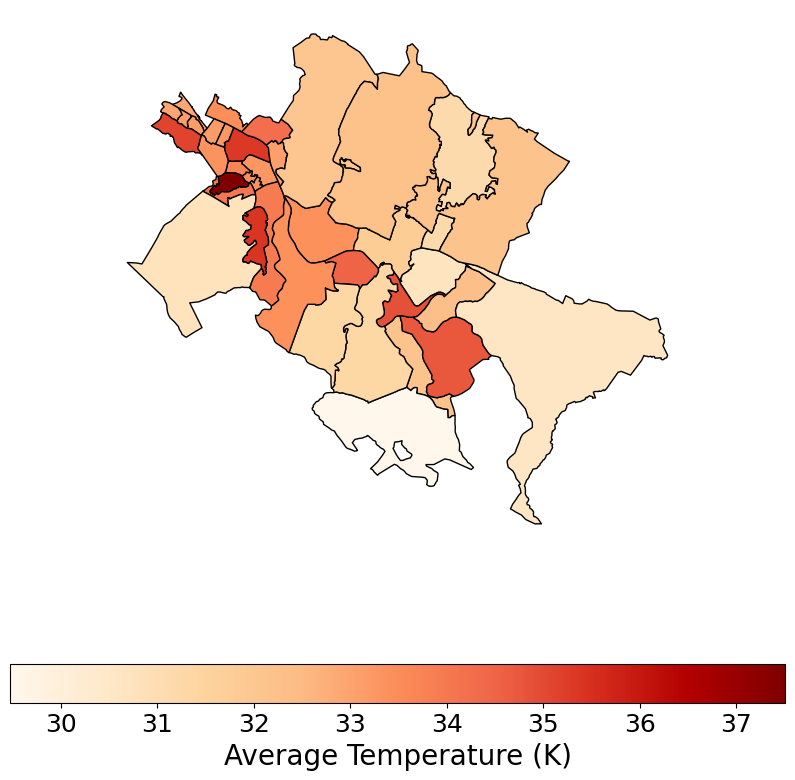

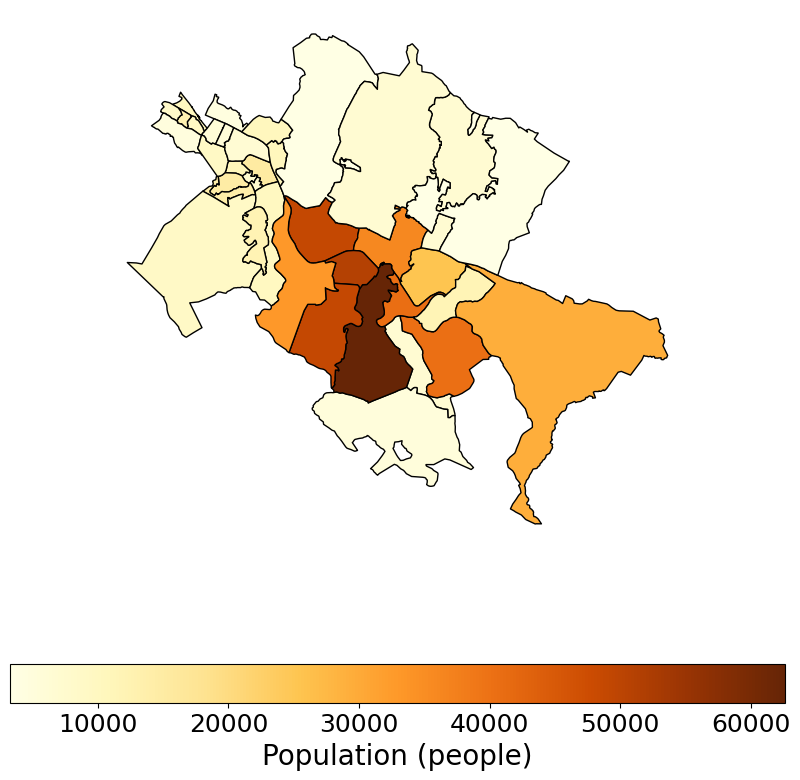

Processing Valladolid…


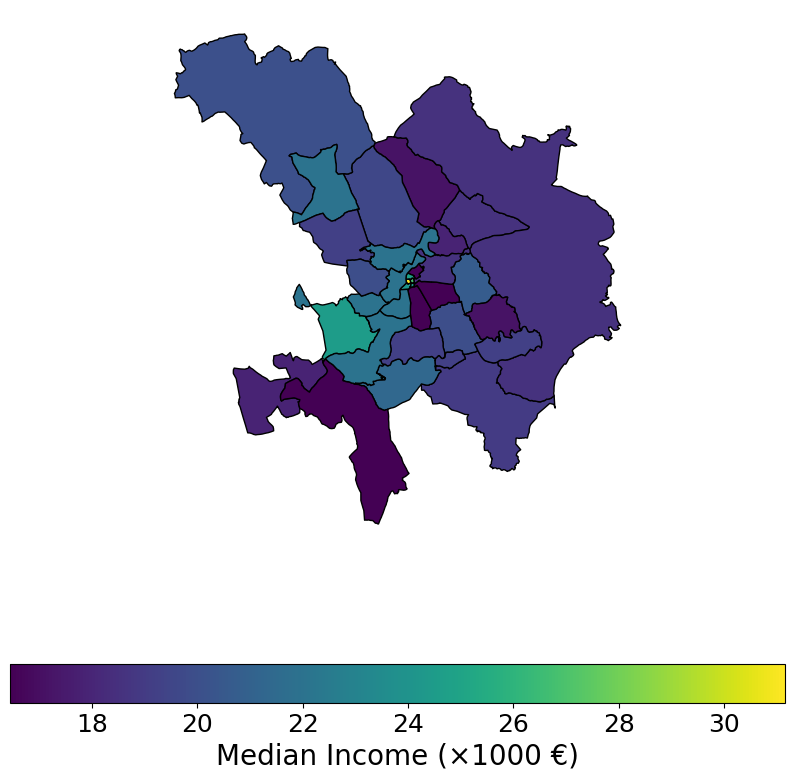

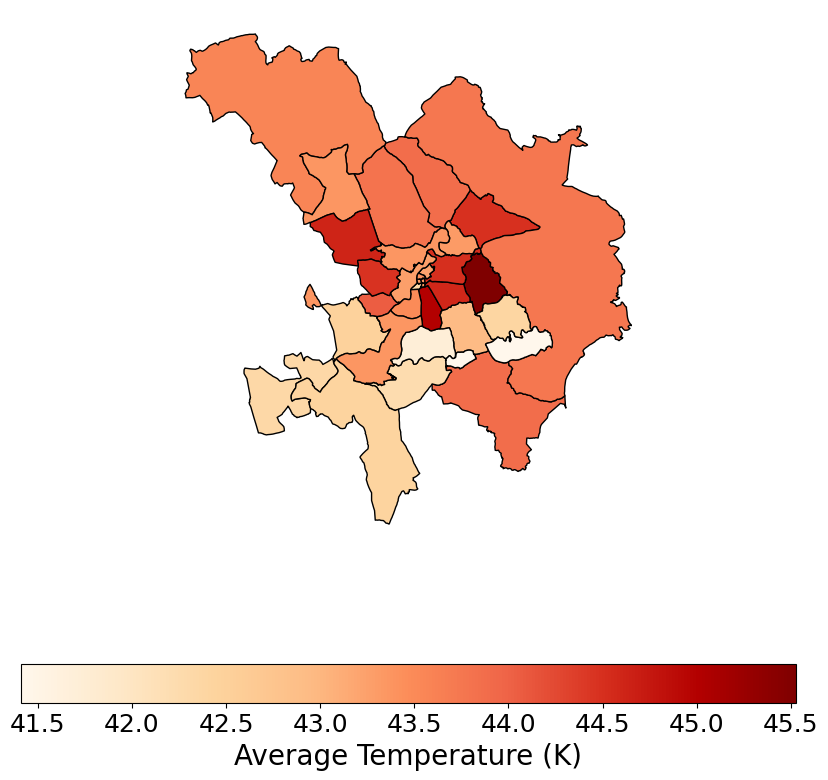

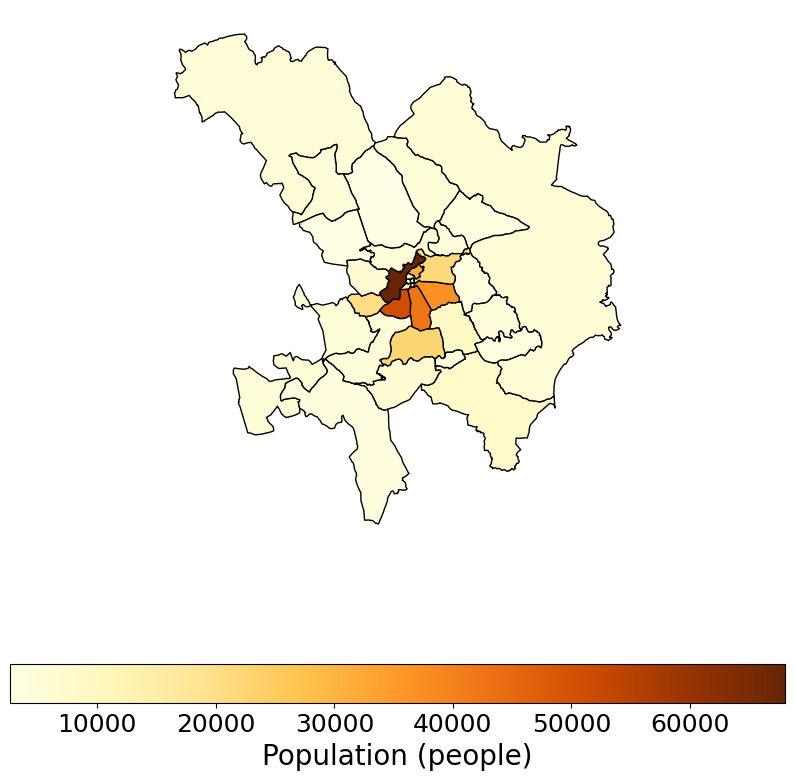

Processing Cordoba…


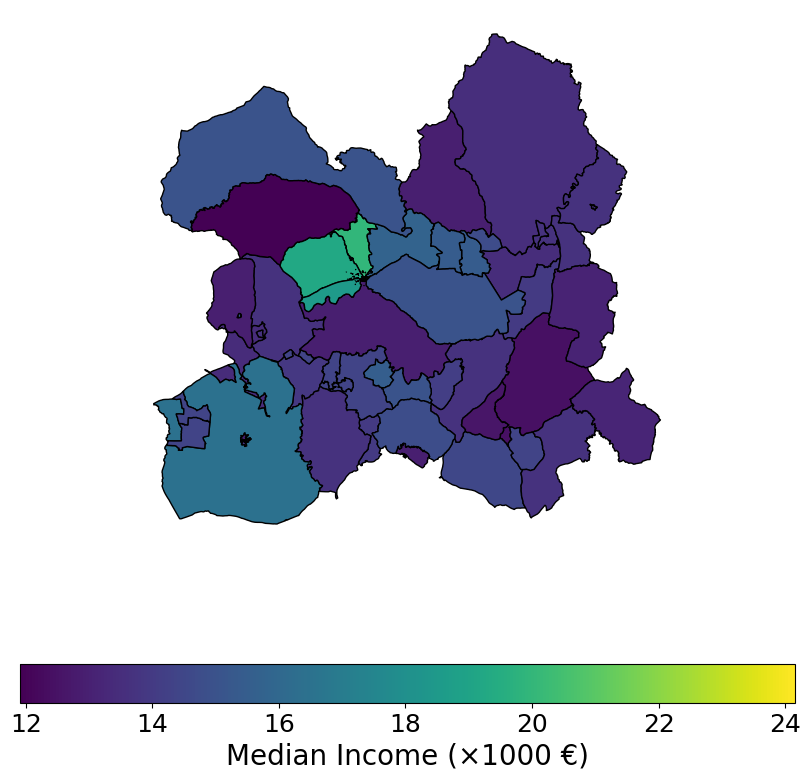

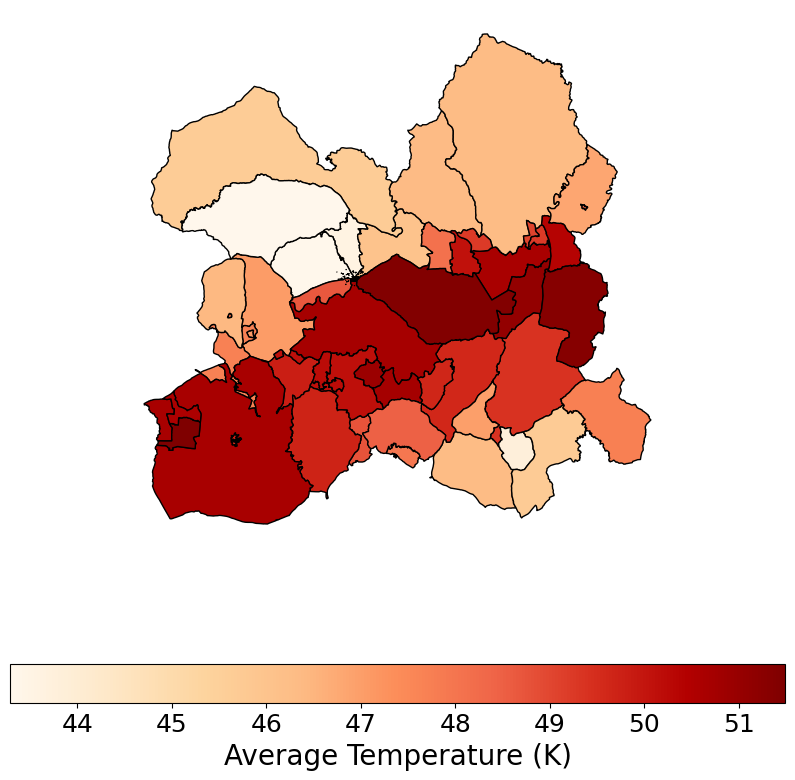

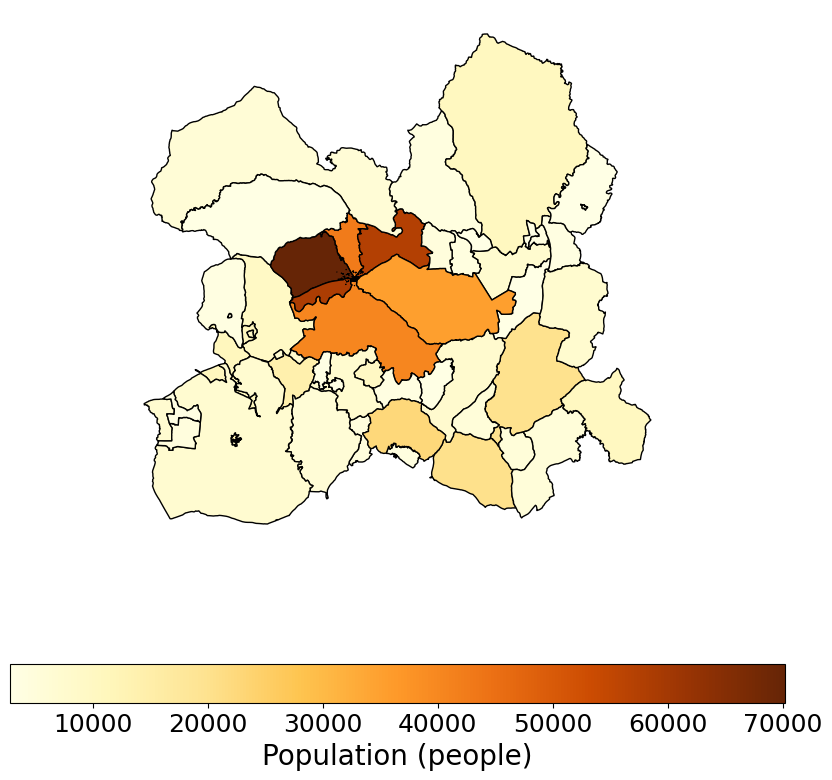

Processing Vigo…


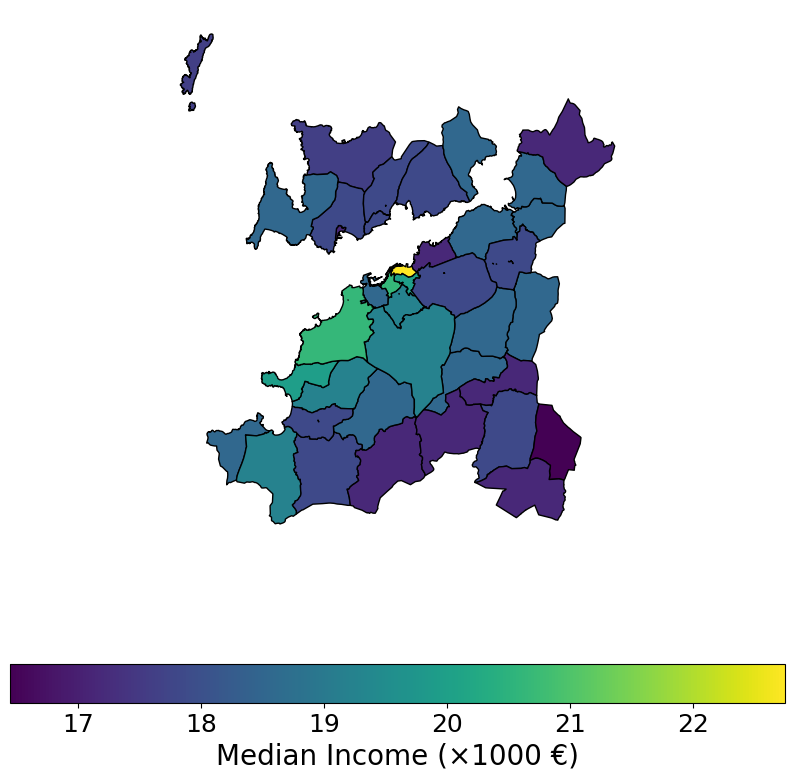

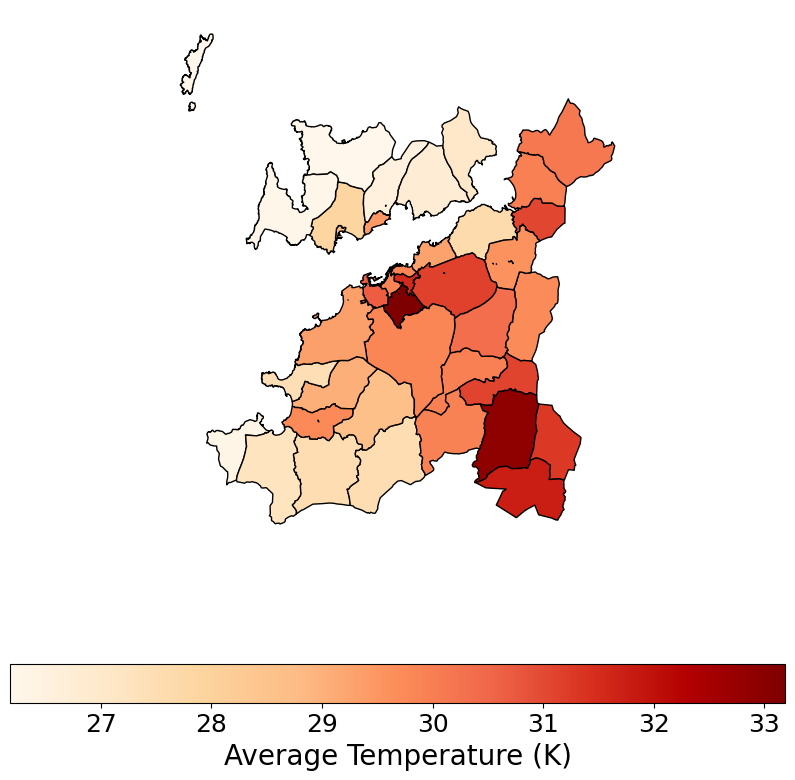

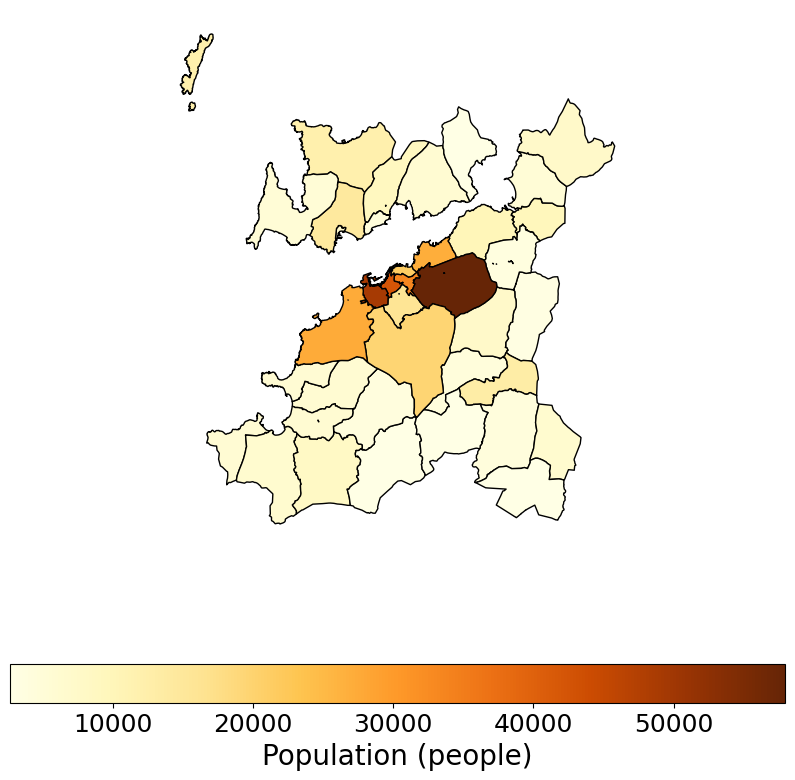

Processing Gijon…


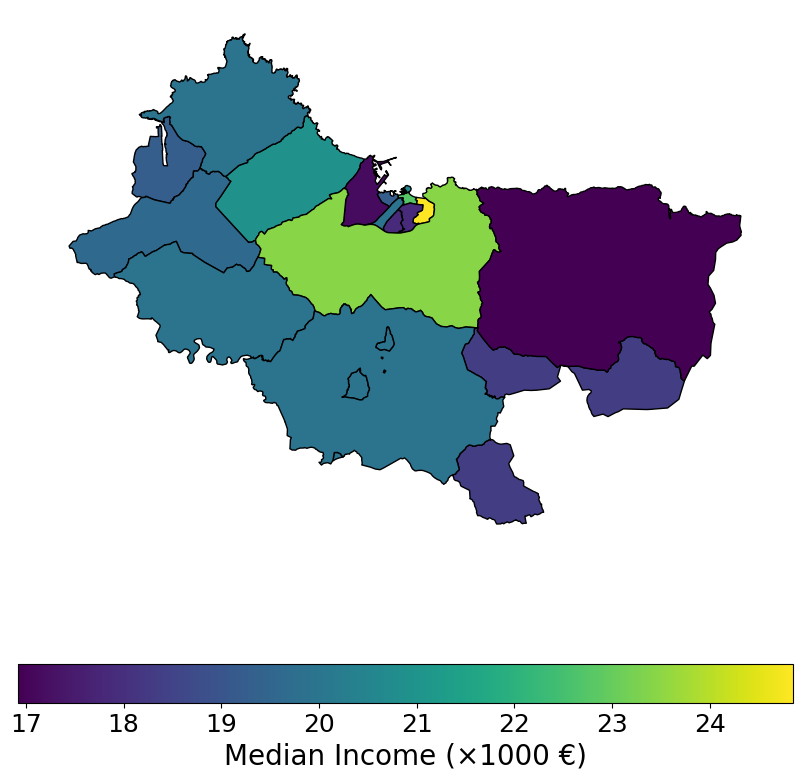

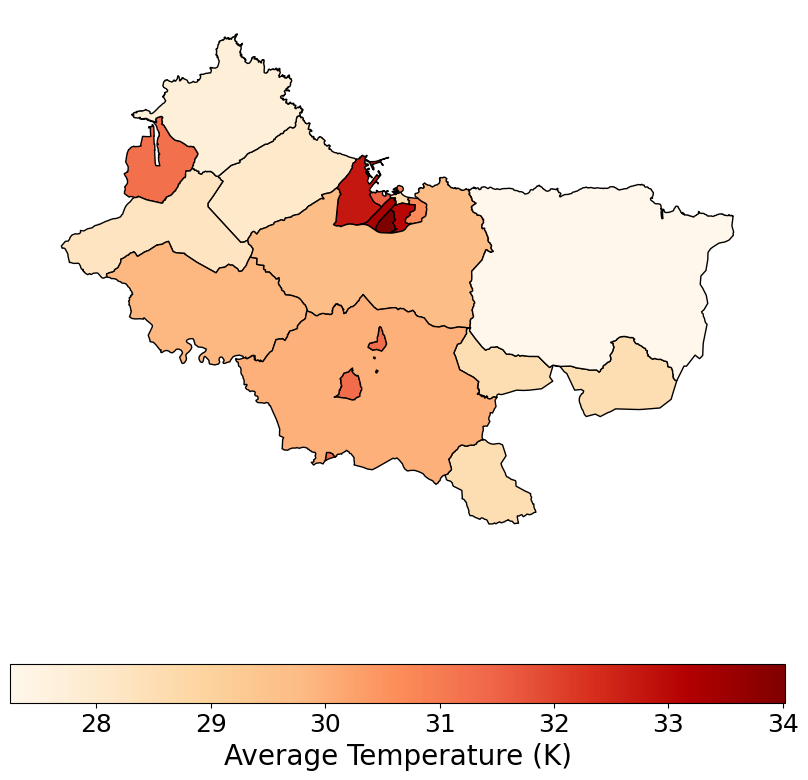

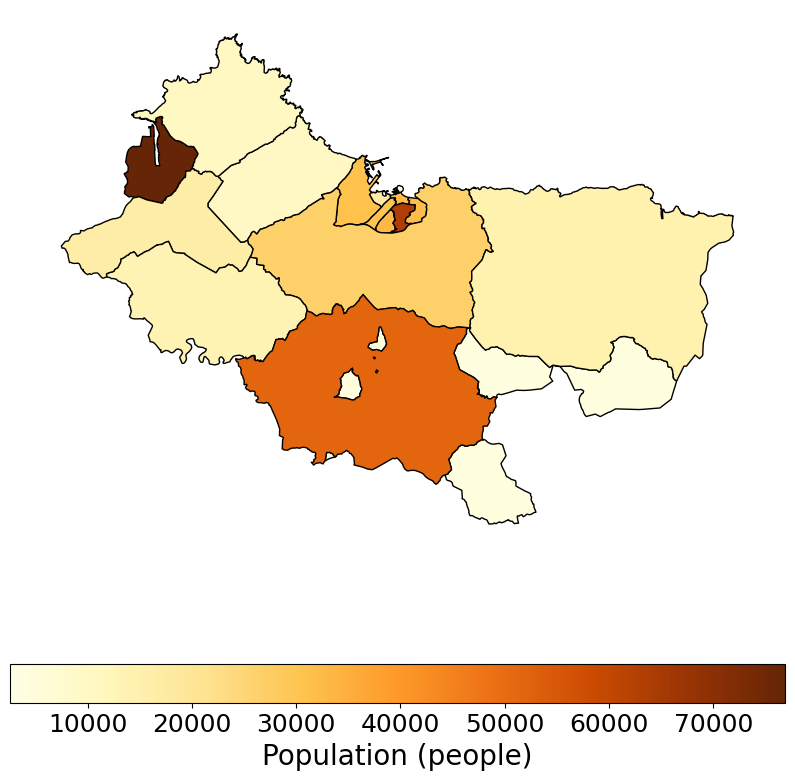

Processing Vitoria_Gasteiz…


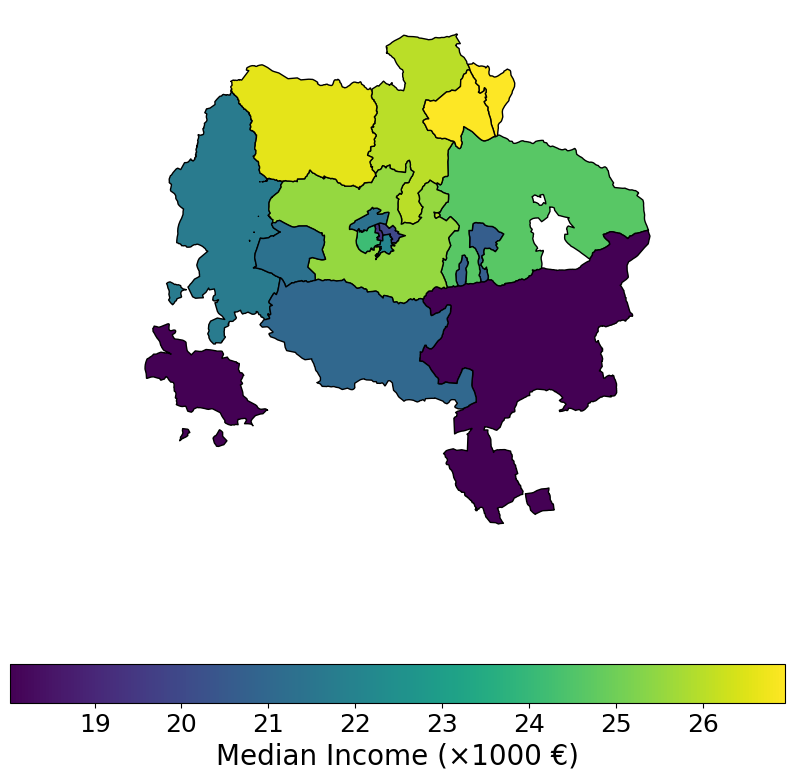

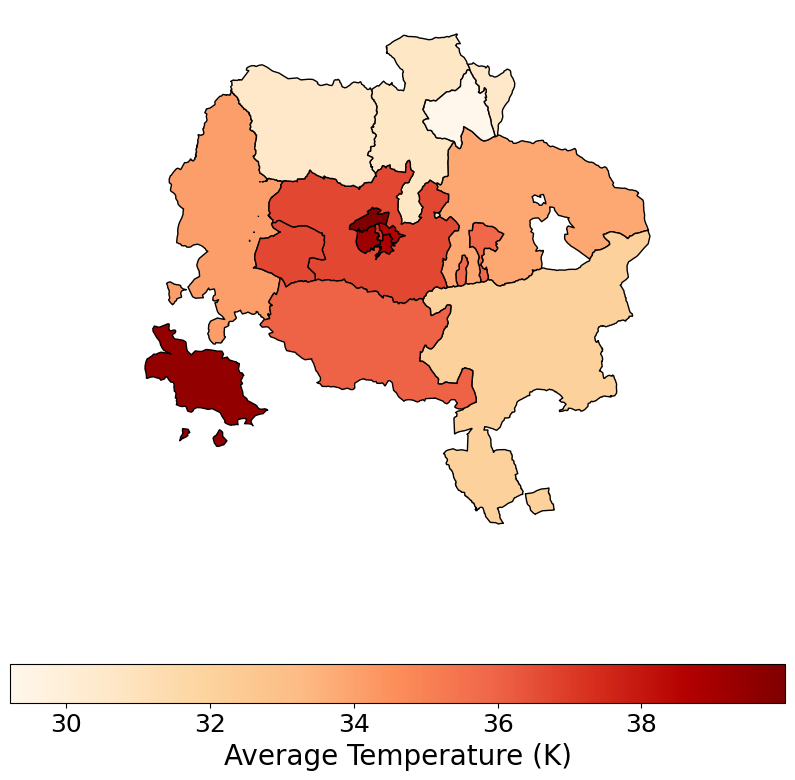

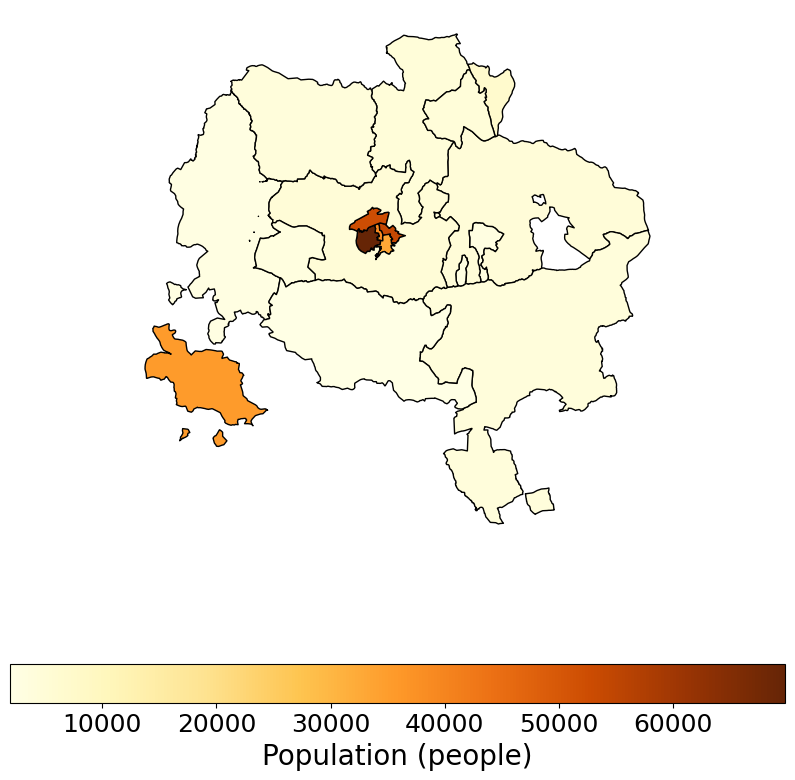

Processing A_Coruna…


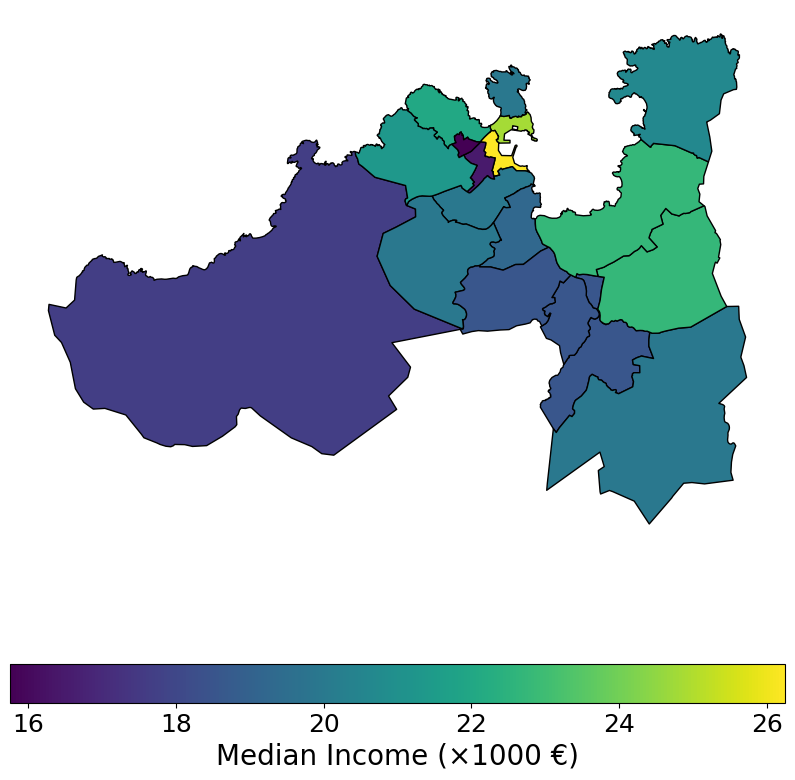

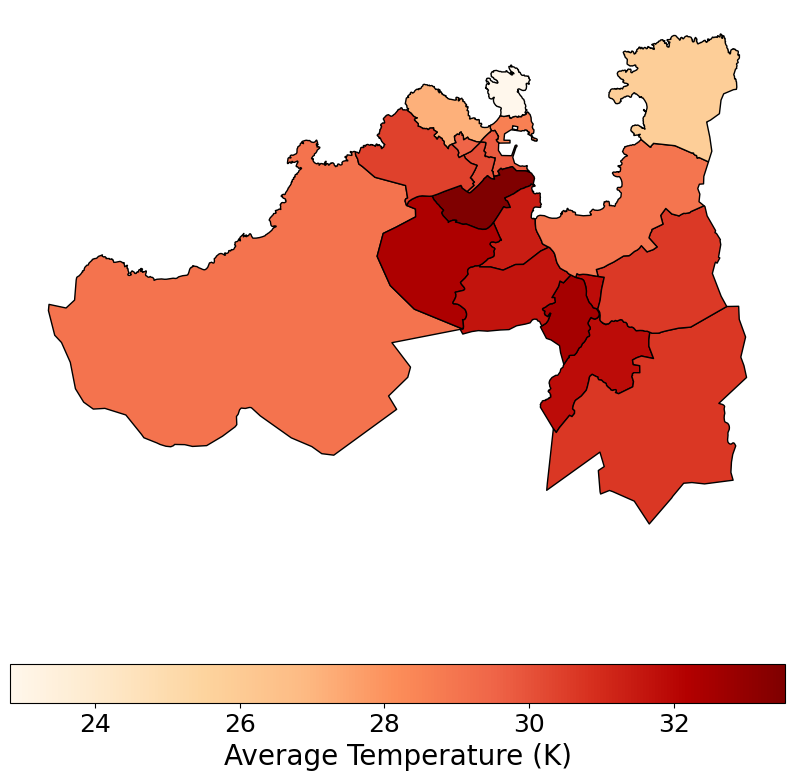

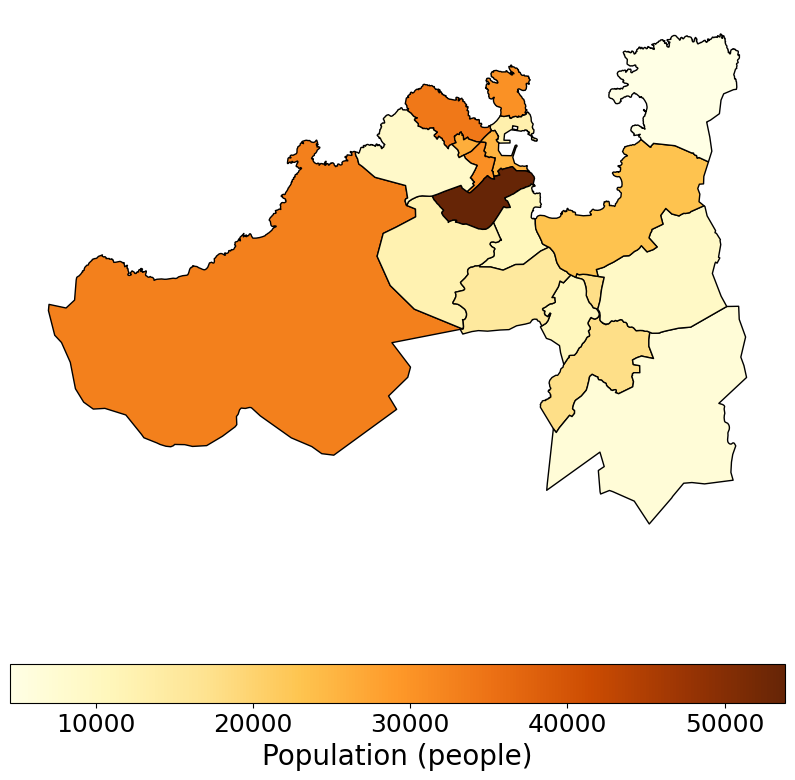

Processing Granada…


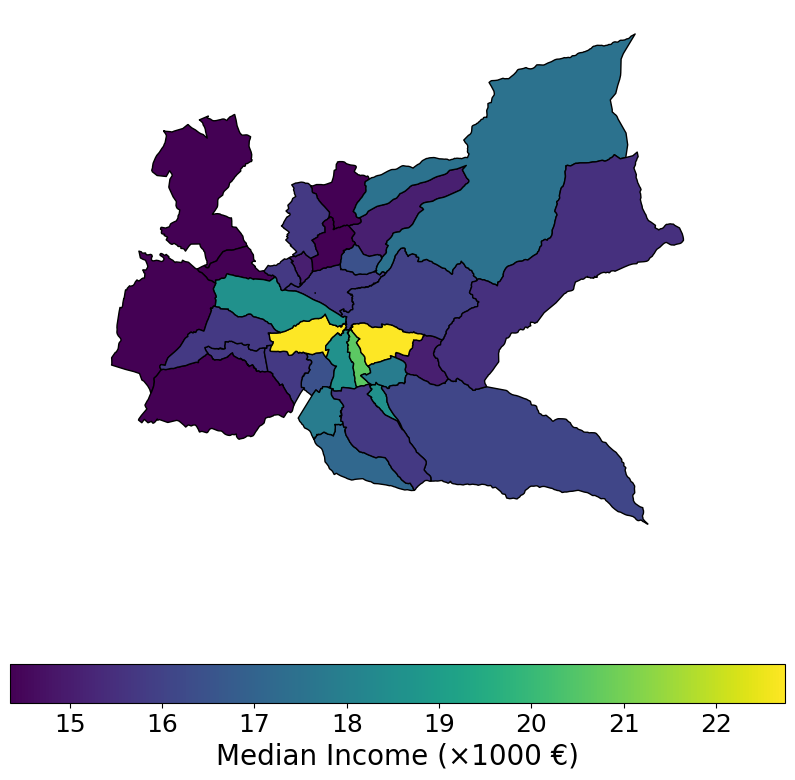

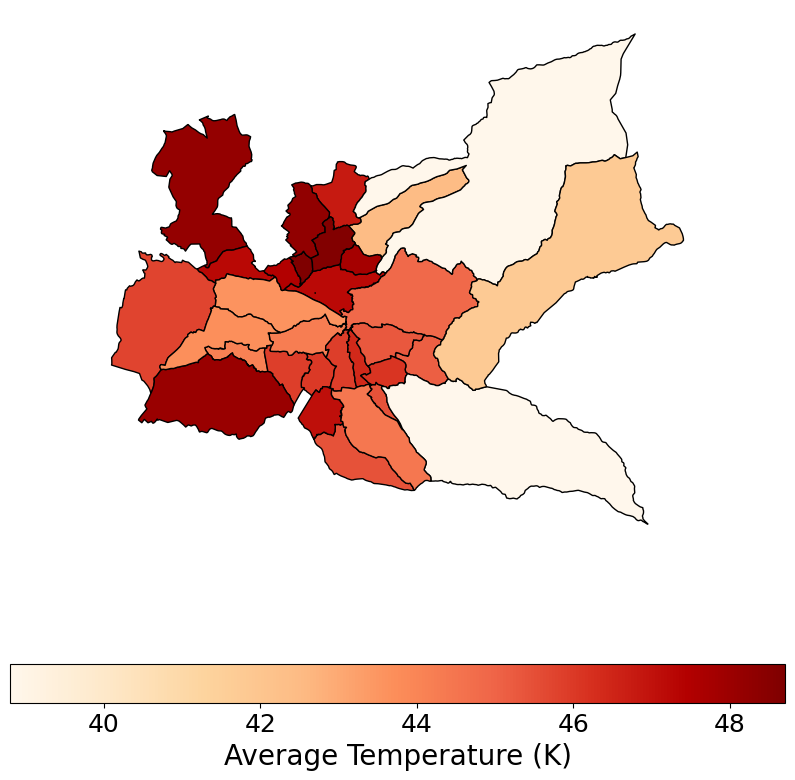

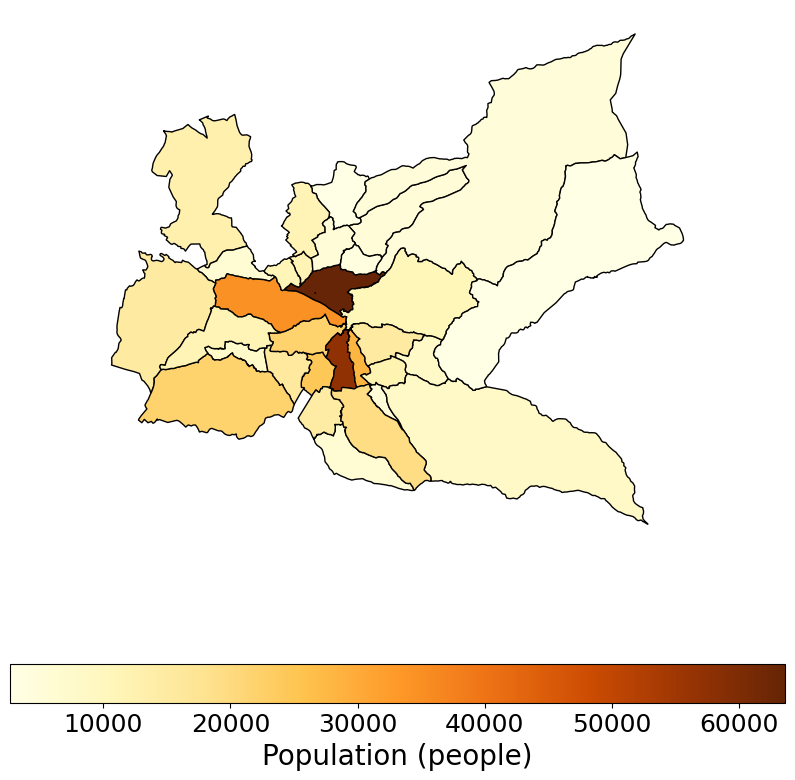

Processing Elche…


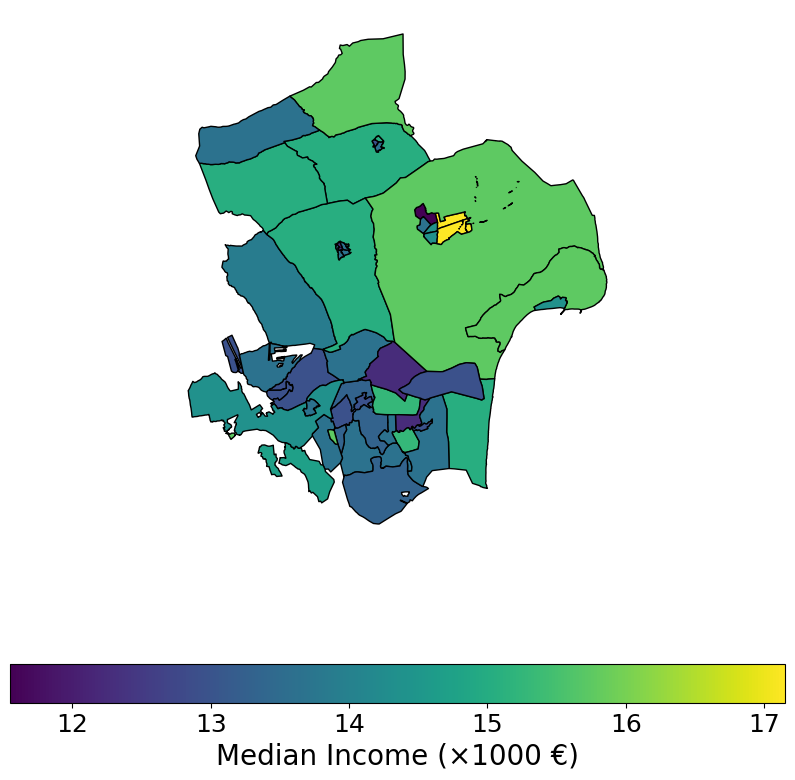

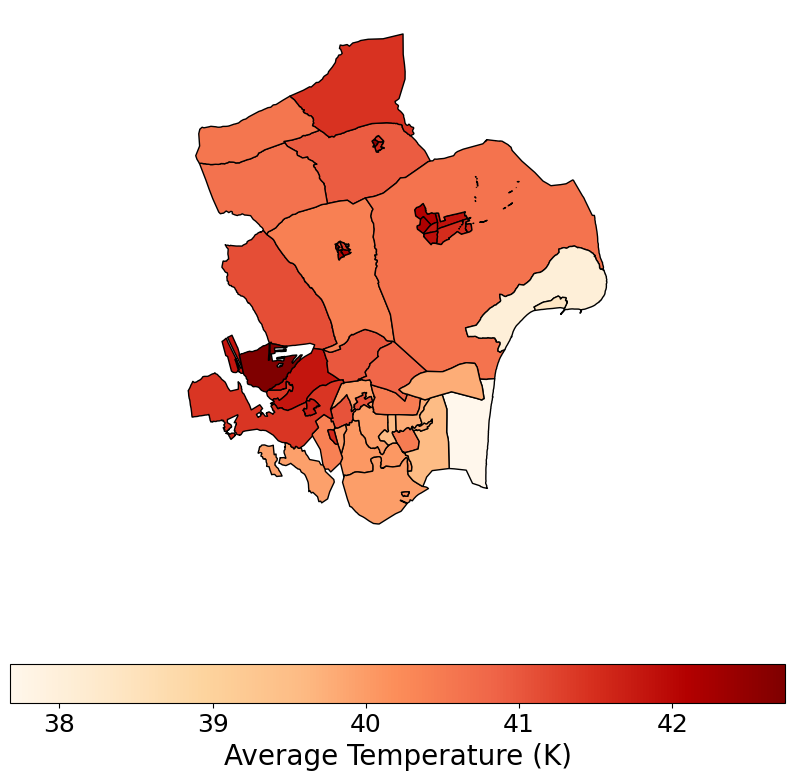

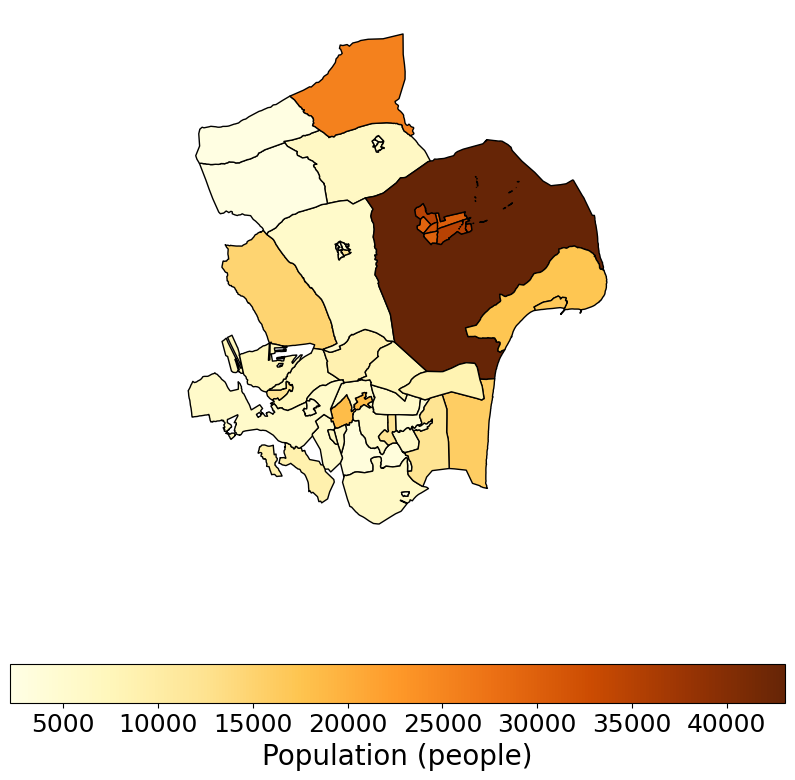

Processing Cartagena…


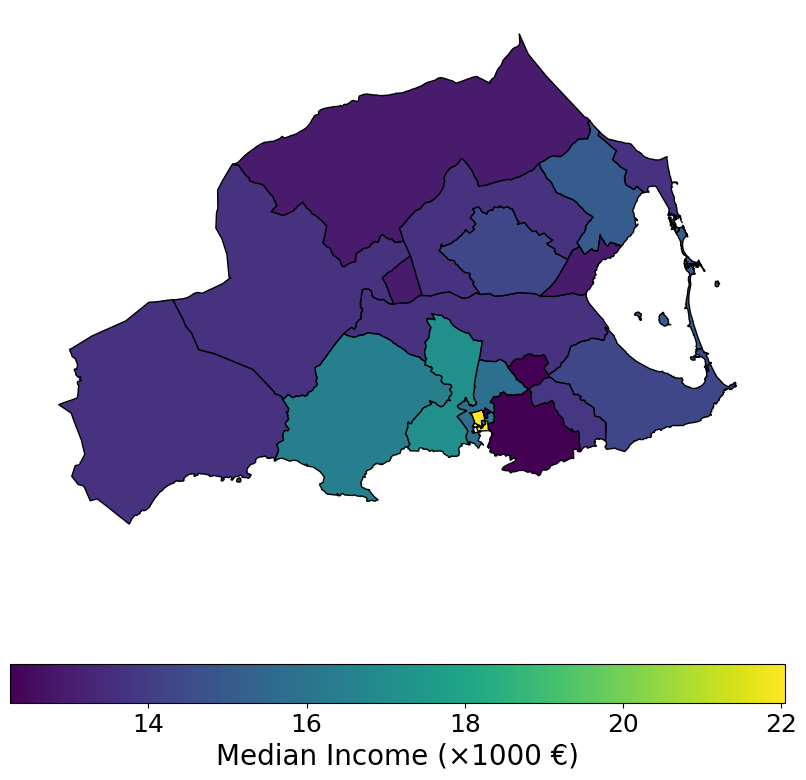

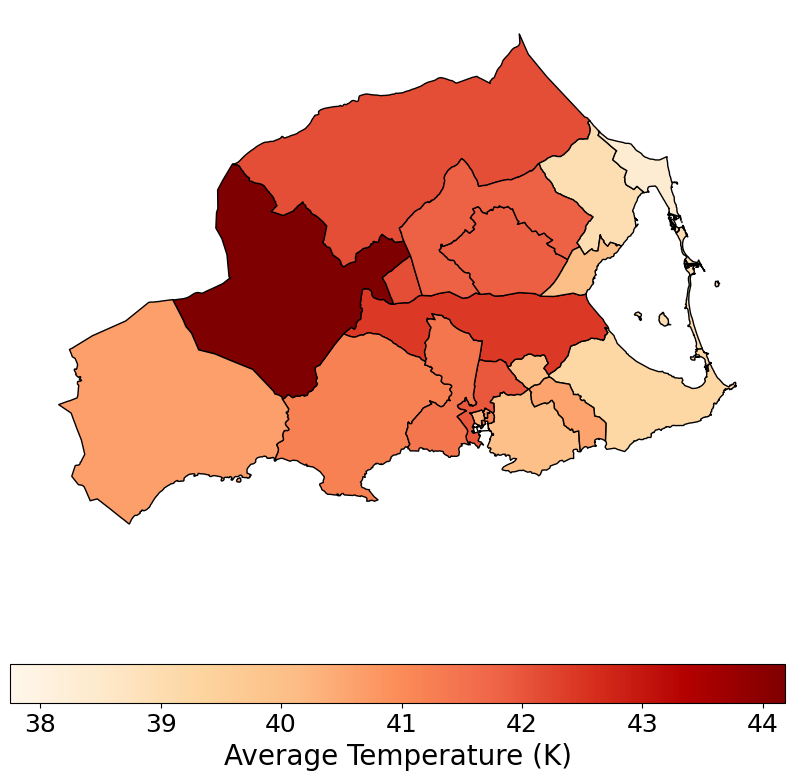

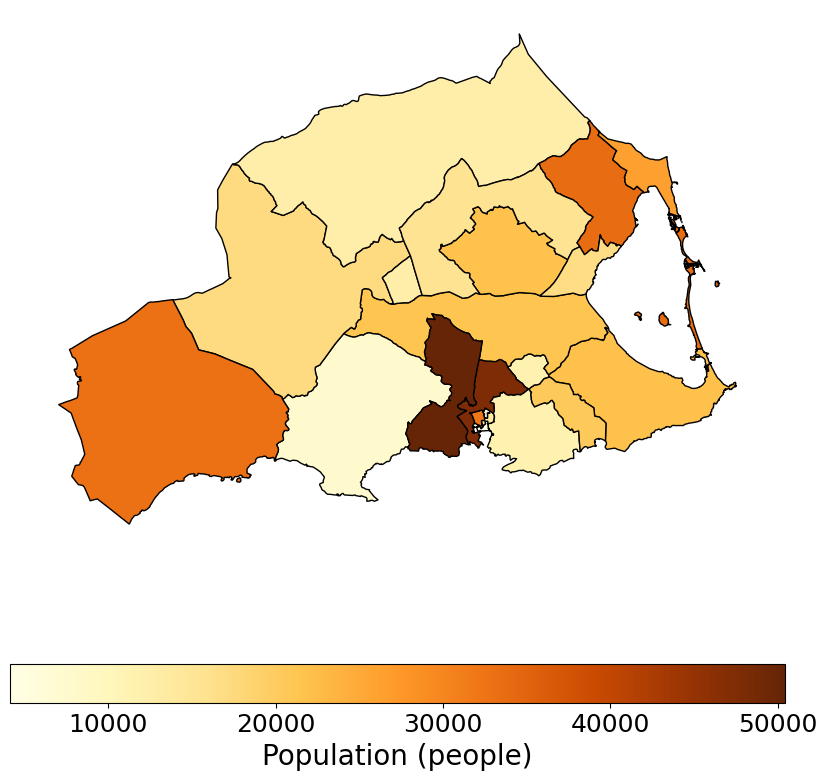

Processing Oviedo…


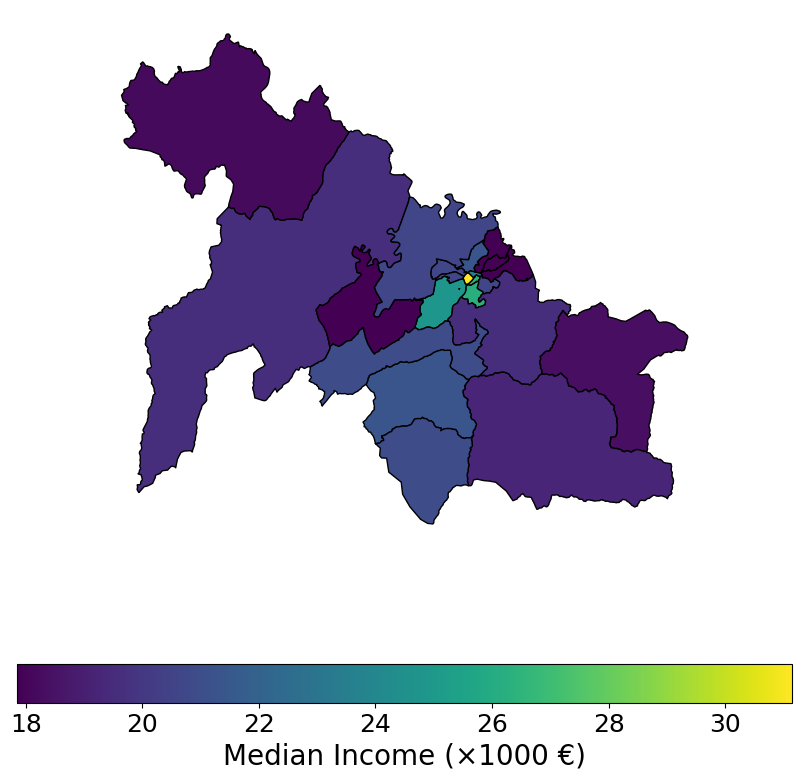

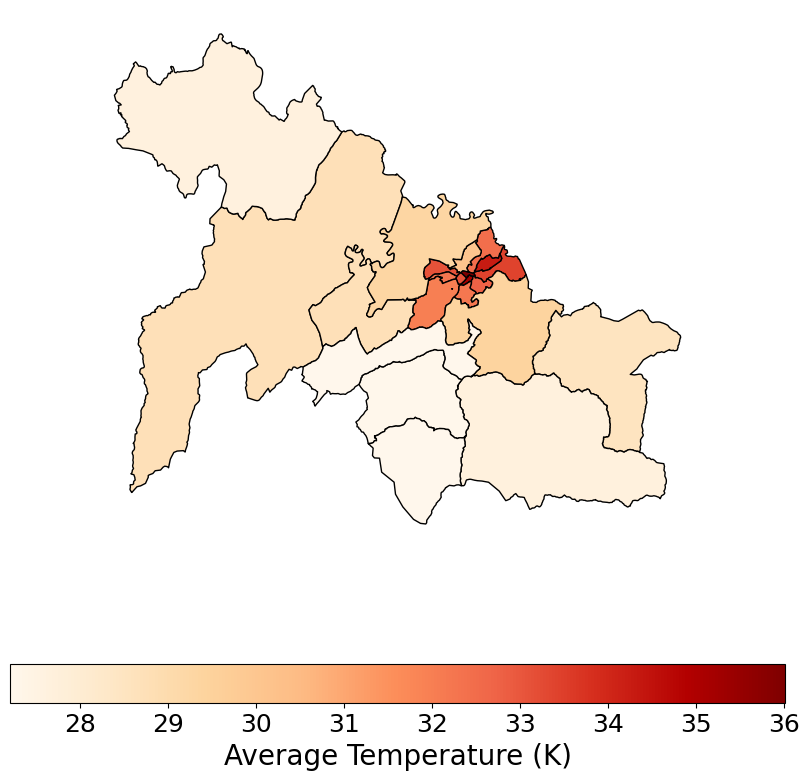

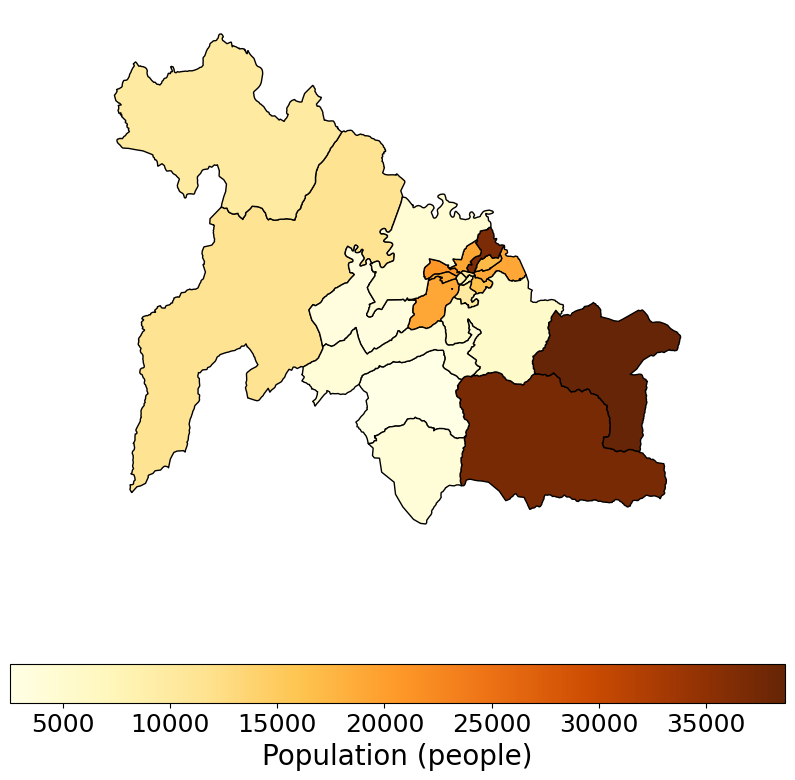

Processing Jerez_de_la_Frontera…


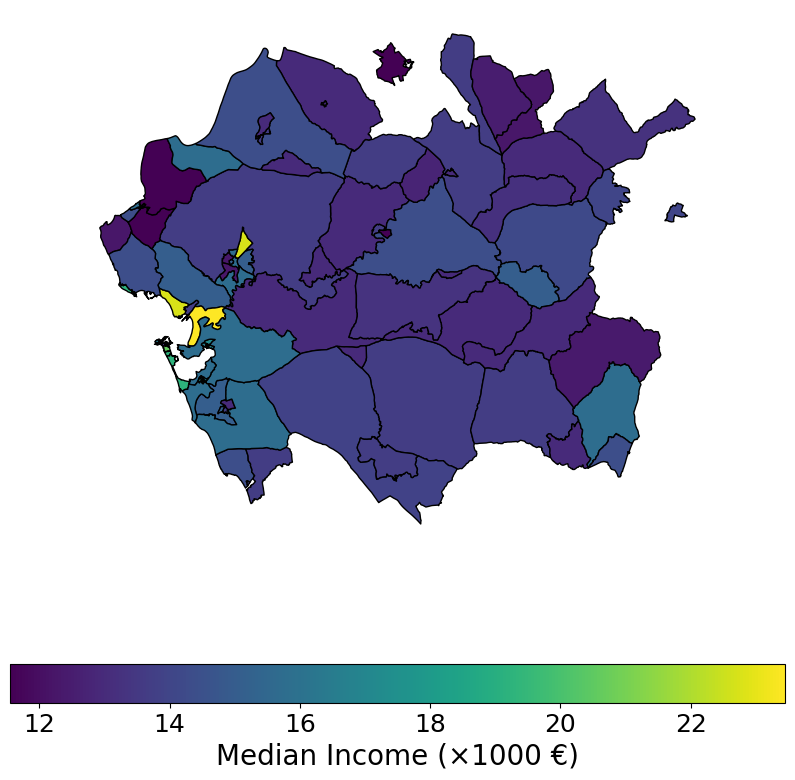

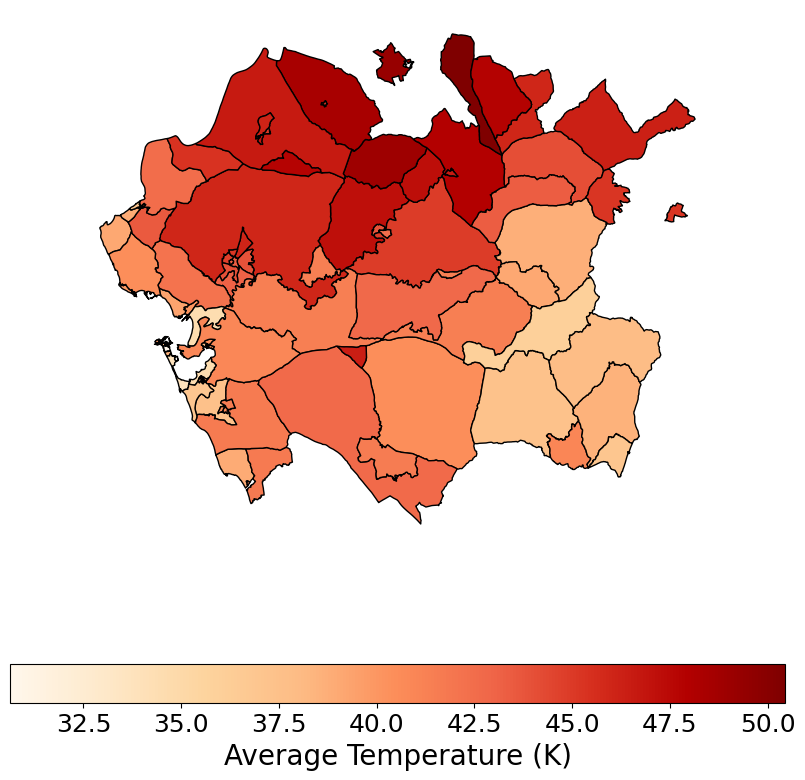

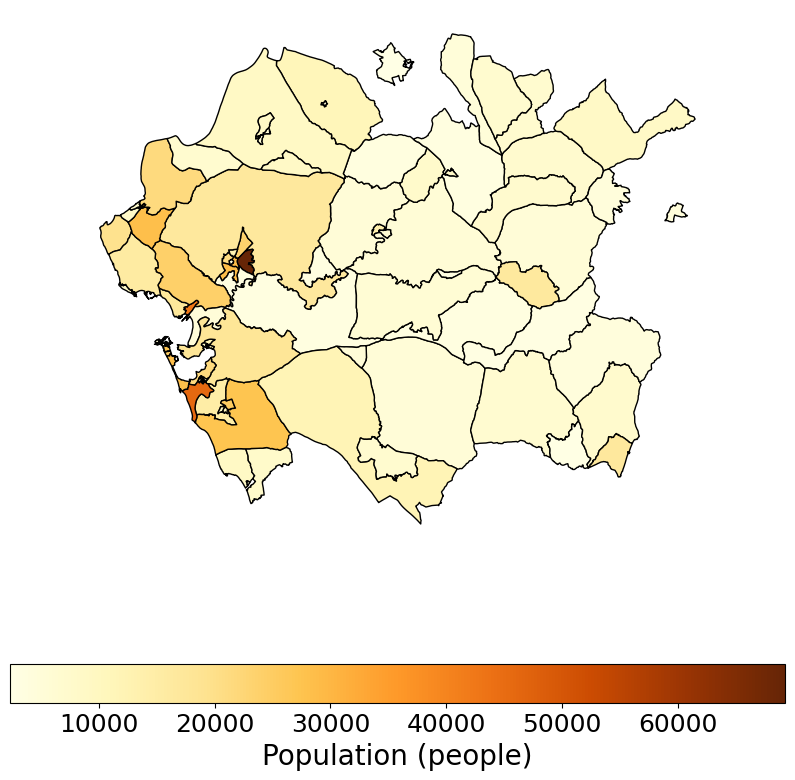

Processing Santa_Cruz_de_Tenerife…


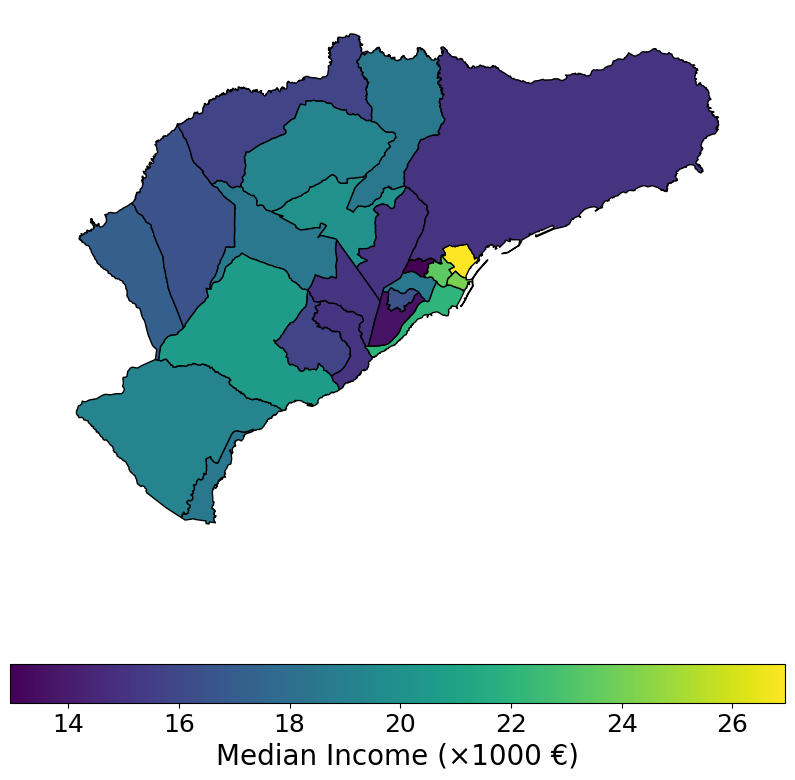

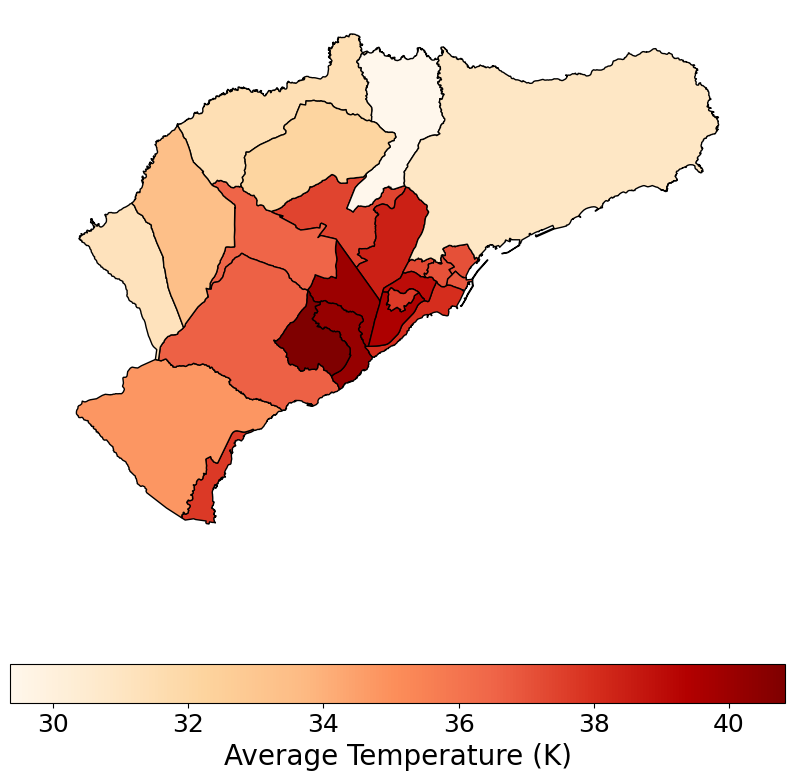

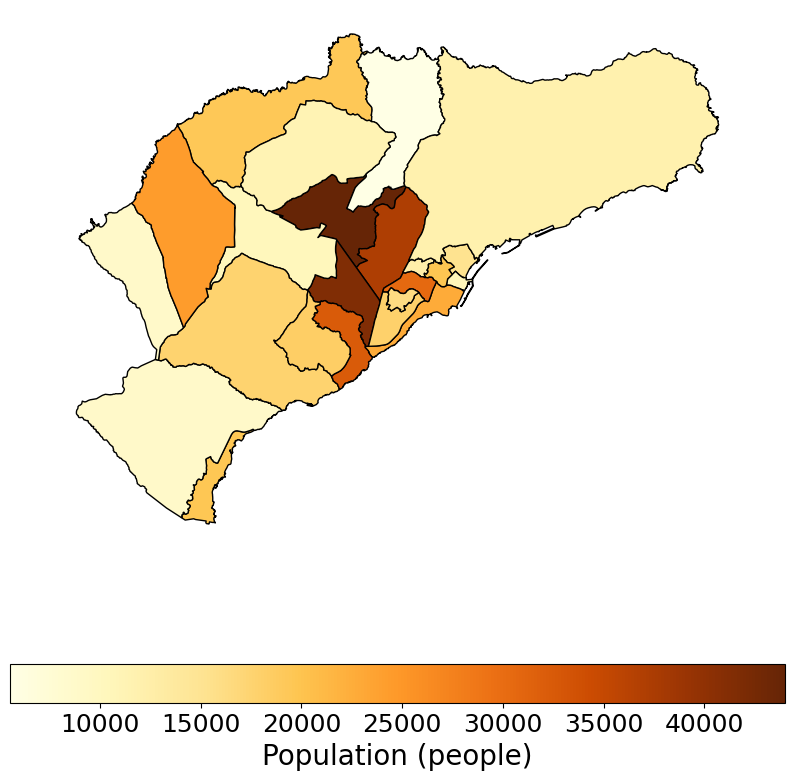

In [12]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2')

crs_trips = "EPSG:32630"
crs_ll    = "EPSG:4326"

bbox_utm_bounds = {}
for city, box_ll in extended_bbox_dict.items():
    box_utm = (
        gpd.GeoSeries([box_ll], crs=crs_ll)
           .to_crs(crs_trips)
           .iloc[0]
    )
    bbox_utm_bounds[city] = box_utm.bounds


for city in cities:
    print(f"Processing {city}…")
    city_gdf = results_districts[city]        
    crs_metric = city_gdf.crs                  

    minx, miny, maxx, maxy = bbox_utm_bounds[city]

    mask = (
        city_gdf['x'].between(minx, maxx) &
        city_gdf['y'].between(miny, maxy)
    )
    city_filtered = city_gdf[mask].copy()
    if city_filtered.empty:
        print(f"  → No districts left inside bbox for {city}, skipping.")
        continue

    def plot_choro(gdf, column, cmap, title, units):
        fig, ax = plt.subplots(figsize=(10,10))
        gdf.plot(
            column=column, cmap=cmap, legend=True,
            ax=ax, edgecolor='black',
            legend_kwds={'label':f"{title} ({units})",'orientation':'horizontal'}
        )
        cbar = ax.get_figure().axes[-1]
        cbar.tick_params(labelsize=18)
        cbar.set_xlabel(f"{title} ({units})", fontsize=20)
        ax.set_axis_off()
        plt.show()

    plot_choro(city_filtered, 'median_revenue_per_consumption','viridis',
               'Median Income','×1000 €')
    plot_choro(city_filtered, 'avg_T','OrRd',
               'Average Temperature','K')
    plot_choro(city_filtered, 'population','YlOrBr',
               'Population','people')

In [13]:
for city, ddf in results_districts.items():
    bb = bbox_utm_bounds.get(city)
    if bb is None:
        continue

    minx, miny, maxx, maxy = bb
    mask = ddf['x'].between(minx, maxx) & ddf['y'].between(miny, maxy)
    results_districts[city] = ddf.loc[mask].copy()
    print(f"{city}: kept {len(results_districts[city])} / {len(ddf)} districts inside bbox")

A_Coruna: kept 18 / 21 districts inside bbox
Alicante: kept 27 / 43 districts inside bbox
Barcelona: kept 107 / 137 districts inside bbox
Bilbao: kept 38 / 60 districts inside bbox
Cartagena: kept 19 / 22 districts inside bbox
Cordoba: kept 54 / 77 districts inside bbox
Elche: kept 42 / 54 districts inside bbox
Gijon: kept 18 / 22 districts inside bbox
Granada: kept 31 / 45 districts inside bbox
Jerez_de_la_Frontera: kept 86 / 101 districts inside bbox
Las_Palmas: kept 19 / 23 districts inside bbox
Madrid: kept 140 / 194 districts inside bbox
Malaga: kept 40 / 55 districts inside bbox
Murcia: kept 32 / 35 districts inside bbox
Oviedo: kept 21 / 25 districts inside bbox
Palma_de_Mallorca: kept 46 / 57 districts inside bbox
Santa_Cruz_de_Tenerife: kept 23 / 28 districts inside bbox
Sevilla: kept 44 / 68 districts inside bbox
Valencia: kept 84 / 103 districts inside bbox
Valladolid: kept 31 / 40 districts inside bbox
Vigo: kept 38 / 49 districts inside bbox
Vitoria_Gasteiz: kept 17 / 24 d

# OPEN MERGE DATA (mobility + districts)

In [15]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2\dataframes')

mobs_daily = {}

for city in cities:
    
    df = pd.concat([
        pd.read_csv(f'{city}_mob_daily{d}.csv', dtype={'origen': str, 'destino': str})
          .assign(
              year  = int(d[-4:]),
              month = int(d[1:3])   
          )
        for d in dates
    ], ignore_index=True)

    yearly_avg = df.groupby('year')['avg_T_origen'].mean()
    print(f"\nAverage origin temperature per year in {city}:")
    print(yearly_avg.to_string(), "\n")

    df['day']     = df['day'].astype(int)
    df['date']    = pd.to_datetime(df[['year','month','day']])
    df['weekday'] = df['date'].dt.weekday
    df = df.drop(columns=['year','month','day'])

    env_cols = [
        'avg_T_origen', 'median_income_per_consumption_origen','population_origen'
    ]
    env_month = (
        df
          .groupby([df['date'].dt.year, df['date'].dt.month, 'origen'], as_index=False)[env_cols]
          .mean()
          .rename(columns={
              'origen':       'district_id',
              'avg_T_origen': 'avg_T',
              'median_income_per_consumption_origen':'income',
              'population_origen':'population'
          })
    )
    env_mean = (
        env_month
          .groupby('district_id', as_index=False)
          .agg({
              'avg_T'     :'mean',
              'income'    :'mean',
              'population':'mean'
          })
    )

    df = (
        df
          .merge(env_mean, left_on='origen', right_on='district_id', how='left')
          .drop(columns=[
              'avg_T_origen', 'median_income_per_consumption_origen','population_origen',
              'district_id'
          ])
          .rename(columns={
              'avg_T'     : 'avg_T_origen',
              'income'    : 'median_income_per_consumption_origen',
              'population': 'population_origen'
          })
    )
    df = (
        df
          .merge(env_mean, left_on='destino', right_on='district_id', how='left')
          .drop(columns=[
              'avg_T','income','population','district_id'
          ])
          .rename(columns={
              'avg_T'     : 'avg_T_destino',
              'income'    : 'median_income_per_consumption_destino',
              'population': 'population_destino'
          })
    )

    key_cols = [
        'date','origen','destino','weekday',
        'actividad_origen','actividad_destino',
        'renta','edad'
    ]
    fixed_cols = [
        'avg_T_origen','median_income_per_consumption_origen','population_origen',
        'avg_T_destino','median_income_per_consumption_destino','population_destino',
        'distance','x_orig','y_orig','x_dest','y_dest'
    ]
    agg = {'viajes':'sum'}
    agg.update({c:'first' for c in fixed_cols})

    mobs_daily[city] = df.groupby(key_cols, as_index=False).agg(agg)
    print(f"{city}: {len(mobs_daily[city]):,} filas  |  flows tot = {mobs_daily[city]['viajes'].sum():,}")


Average origin temperature per year in Madrid:
year
2022    45.524718
2023    45.947597 



C:\Users\mduran\AppData\Local\Temp\ipykernel_22700\2934451626.py:41: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .mean()


Madrid: 32,934,386 filas  |  flows tot = 2,325,687,335.3653426

Average origin temperature per year in Barcelona:
year
2022    37.818219
2023    38.229794 



C:\Users\mduran\AppData\Local\Temp\ipykernel_22700\2934451626.py:41: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .mean()


Barcelona: 28,104,839 filas  |  flows tot = 1,655,719,096.4059978

Average origin temperature per year in Valencia:
year
2022    39.559859
2023    38.912617 



...

Oviedo: 1,710,763 filas  |  flows tot = 113,527,936.50773953

Average origin temperature per year in Jerez_de_la_Frontera:
year
2022    39.591955
2023    41.319240 



C:\Users\mduran\AppData\Local\Temp\ipykernel_22700\2934451626.py:41: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .mean()


Jerez_de_la_Frontera: 7,609,935 filas  |  flows tot = 574,319,414.9393146

Average origin temperature per year in Santa_Cruz_de_Tenerife:
year
2022    36.73851
2023    36.26127 



C:\Users\mduran\AppData\Local\Temp\ipykernel_22700\2934451626.py:41: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .mean()


Santa_Cruz_de_Tenerife: 3,908,454 filas  |  flows tot = 312,120,531.24921566


In [17]:
def mem_MB(df):
    return df.memory_usage(deep=True).sum() / 1_048_576

cat_cols   = ['origen','destino',
              'actividad_origen','actividad_destino',
              'renta','edad']

float_cols = ['avg_T_origen','avg_T_destino',
              'population_origen','population_destino',
              'distance','x_orig','y_orig','x_dest','y_dest']

for city, df in mobs_daily.items():
    print(f'\n{city}  — before : {mem_MB(df):,.1f} MB')

    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    for col in float_cols:
        if col in df.columns:
            df[col] = df[col].astype('float32')          

    mobs_daily[city] = df 

    print(f'{city}  — after  : {mem_MB(df):,.1f} MB')


Madrid  — before : 13,932.0 MB
Madrid  — after  : 2,512.7 MB

Barcelona  — before : 11,890.5 MB
Barcelona  — after  : 2,144.3 MB

Valencia  — before : 7,267.0 MB
Valencia  — after  : 1,278.7 MB

Zaragoza  — before : 1,482.9 MB
Zaragoza  — after  : 259.8 MB

Sevilla  — before : 3,228.5 MB
Sevilla  — after  : 568.4 MB

Malaga  — before : 2,500.1 MB
Malaga  — after  : 438.6 MB

Murcia  — before : 1,261.4 MB
Murcia  — after  : 222.3 MB

Palma_de_Mallorca  — before : 1,644.7 MB
Palma_de_Mallorca  — after  : 288.3 MB

Las_Palmas  — before : 812.1 MB
Las_Palmas  — after  : 142.7 MB

Alicante  — before : 1,461.8 MB
Alicante  — after  : 256.1 MB

Bilbao  — before : 2,885.1 MB
Bilbao  — after  : 507.2 MB

Valladolid  — before : 1,265.7 MB
Valladolid  — after  : 221.9 MB

Cordoba  — before : 1,369.1 MB
Cordoba  — after  : 241.0 MB

Vigo  — before : 1,583.0 MB
Vigo  — after  : 277.4 MB

Gijon  — before : 837.4 MB
Gijon  — after  : 147.1 MB

Vitoria_Gasteiz  — before : 516.9 MB
Vitoria_Gasteiz  — 

In [19]:
crs_trips = "EPSG:32630"
crs_ll    = "EPSG:4326" 

bbox_utm_bounds = {}
for city in mobs_daily:
    poly_ll = Polygon([
        (xmin[city], ymin[city]),
        (xmin[city], ymax[city]),
        (xmax[city], ymax[city]),
        (xmax[city], ymin[city]),
    ])
    poly_utm = (
        gpd.GeoSeries([poly_ll], crs=crs_ll)
           .to_crs(crs_trips)
           .iloc[0]
    )
    bbox_utm_bounds[city] = poly_utm.bounds 

for city, df in mobs_daily.items():
    
    # --- Check ---
    minx, miny, maxx, maxy = bbox_utm_bounds[city]
    origen_utm = df['x_orig'].between(minx, maxx) & df['y_orig'].between(miny, maxy)
    destino_utm = df['x_dest'].between(minx, maxx) & df['y_dest'].between(miny, maxy)
    print(f"{city} (UTM):   origen_dentro={origen_utm.sum()}, destino_dentro={destino_utm.sum()}")
    mask_both = origen_utm & destino_utm
    print(f"{city}: viajes_con_ambos_dentro={mask_both.sum()} / total={len(df)}\n")

    mobs_daily[city] = df[mask_both].copy()

Madrid (UTM):   origen_dentro=29598123, destino_dentro=29682339
Madrid: viajes_con_ambos_dentro=27312046 / total=32934386

Barcelona (UTM):   origen_dentro=23866800, destino_dentro=23944339
Barcelona: viajes_con_ambos_dentro=20966273 / total=28104839

Valencia (UTM):   origen_dentro=15261549, destino_dentro=15400418
Valencia: viajes_con_ambos_dentro=13903219 / total=17189140

Zaragoza (UTM):   origen_dentro=2956678, destino_dentro=2986911
Zaragoza: viajes_con_ambos_dentro=2724203 / total=3492703

Sevilla (UTM):   origen_dentro=6311878, destino_dentro=6387415
Sevilla: viajes_con_ambos_dentro=5440146 / total=7641467

Malaga (UTM):   origen_dentro=5029396, destino_dentro=5074973
Malaga: viajes_con_ambos_dentro=4442679 / total=5896450

Murcia (UTM):   origen_dentro=2831578, destino_dentro=2844488
Murcia: viajes_con_ambos_dentro=2745015 / total=2987677

Palma_de_Mallorca (UTM):   origen_dentro=3248947, destino_dentro=3266575
Palma_de_Mallorca: viajes_con_ambos_dentro=2825045 / total=3875119

In [20]:
district_counts = {
    city: df['origen'].nunique()
    for city, df in mobs_daily.items()
}

district_counts_df = (
    pd.DataFrame.from_dict(district_counts, orient='index', columns=['num_districts'])
      .reset_index()
      .rename(columns={'index': 'city'})
)

print(district_counts_df)

                      city  num_districts
0                   Madrid            140
1                Barcelona            107
2                 Valencia             84
3                 Zaragoza             41
4                  Sevilla             44
5                   Malaga             40
6                   Murcia             32
7        Palma_de_Mallorca             46
8               Las_Palmas             19
9                 Alicante             27
10                  Bilbao             38
11              Valladolid             31
12                 Cordoba             54
13                    Vigo             38
14                   Gijon             18
15         Vitoria_Gasteiz             17
16                A_Coruna             18
17                 Granada             31
18                   Elche             41
19               Cartagena             19
20                  Oviedo             21
21    Jerez_de_la_Frontera             86
22  Santa_Cruz_de_Tenerife        

# SEGREGATION METRICS

In [31]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2')

def rho_assortativity(X_normalized):
    """
    Calculates the Pearson-correlation-based assortativity from a normalized matrix,
    whose row/col correspond to bin labels in [1..n_bins].
    """
    if X_normalized.size == 0 or np.nansum(X_normalized) == 0:
        return np.nan

    n_rows, n_cols = X_normalized.shape
    row_vals = np.arange(1, n_rows+1)
    col_vals = np.arange(1, n_cols+1)

    # sum_{i,j}( i*j*X_ij )
    sum_ij = 0.0
    for i in range(n_rows):
        for j in range(n_cols):
            sum_ij += row_vals[i] * col_vals[j] * X_normalized[i,j]

    # sum_i, sum_j
    sum_i = 0.0
    for i in range(n_rows):
        sum_i += row_vals[i] * np.sum(X_normalized[i,:])
    sum_j = 0.0
    for j in range(n_cols):
        sum_j += col_vals[j] * np.sum(X_normalized[:,j])

    numerator = sum_ij - (sum_i * sum_j)

    # denominator
    sum_i2 = 0.0
    for i in range(n_rows):
        sum_i2 += (row_vals[i]**2) * np.sum(X_normalized[i,:])
    sum_j2 = 0.0
    for j in range(n_cols):
        sum_j2 += (col_vals[j]**2) * np.sum(X_normalized[:,j])

    denom = np.sqrt(sum_i2 - sum_i**2) * np.sqrt(sum_j2 - sum_j**2)
    if denom == 0:
        return np.nan
    return round(numerator / denom, 3)

def total_exposure(X):
    """
    E = (sum_{i,j}(X_ij * j)) / (sum_{i,j}(X_ij)),
    where j in [1..n_bins] are the columns (destination bins).
    """
    total = X.values.sum()
    if total == 0:
        return np.nan

    weighted_sum = 0.0
    for j_bin in X.columns:  
        weighted_sum += j_bin * X[j_bin].sum()
    return round(weighted_sum / total, 3)

def exposure_directional_index(X_normalized):
    """
    R = (X_upper - X_lower)/(X_upper + X_lower),
    where X_upper = sum of X_ij for j>i, X_lower = sum of X_ij for j<i.
    X_norm is normalized so sum(X_norm)=1, with row/col in [1..n_bins].
    """
    if X_normalized.values.sum() == 0:
        return np.nan

    upper = 0.0
    lower = 0.0
    row_bins = X_normalized.index
    col_bins = X_normalized.columns

    for i_idx, i_bin in enumerate(row_bins):
        for j_idx, j_bin in enumerate(col_bins):
            val = X_normalized.iloc[i_idx, j_idx]
            if j_bin > i_bin:
                upper += val
            elif j_bin < i_bin:
                lower += val

    denom = upper + lower
    if denom == 0:
        return np.nan
    return round((upper - lower) / denom, 3)

def exposure_directional_index_row(X):
    """
    Compute the directional index R on a row-normalized basis.
    
    For each row i (representing an origin), normalize the row so that:
        p_ij = X[i, j] / sum_j X[i, j]
    Then, compute for each row:
        R_i = (sum_{j > i} p_ij - sum_{j < i} p_ij) / (sum_{j > i} p_ij + sum_{j < i} p_ij)
    Finally, return the average R across all rows that have trips.
    
    Parameters:
        X : pandas.DataFrame
            The OD matrix (raw trip counts) with rows and columns ordered 
            such that lower triangle corresponds to destinations with higher levels 
            (e.g., risk or income) compared to the origin.
    
    Returns:
        float
            The average directional index R (rounded to 3 decimals). Returns np.nan if no row contains trips.
    """
    r_values = []
    for i_idx, i_bin in enumerate(X.index):
        row_total = X.iloc[i_idx, :].sum()
        if row_total == 0:
            continue  # skip rows with no trips
        # Normalize the row
        p_row = X.iloc[i_idx, :] / row_total
        upper = 0.0
        lower = 0.0
        for j_idx, j_bin in enumerate(X.columns):
            if j_bin > i_bin:
                upper += p_row.iloc[j_idx]
            elif j_bin < i_bin:
                lower += p_row.iloc[j_idx]
        denom = upper + lower
        if denom == 0:
            continue
        r_values.append((upper - lower) / denom)
    
    if len(r_values) == 0:
        return np.nan
    return round(np.mean(r_values), 3)

# DAILY

In [29]:
n_bins = 10 

bin_maps = {}
for city, ddf in results_districts.items():
    bins = (
        pd.qcut(ddf['avg_T'], q=n_bins, labels=False)
          .add(1)                   # 0‒9 → 1‒10
          .astype('Int8')
    )
    bin_maps[city] = dict(zip(ddf['ID'].to_numpy(), bins.to_numpy()))

In [120]:
WORK      = ['trabajo_estudio']
FREQUENT  = ['frecuente']
NONROUT   = ['no_frecuente']

ROUTINE = WORK

def day_stats_weighted(df, metric_col, smooth_window=2):
    def w_stats(g):
        x = g[metric_col].to_numpy(float)
        w = g['city_pop'].to_numpy(float)

        mask = np.isfinite(x) & np.isfinite(w) & (w > 0)
        x, w = x[mask], w[mask]
        if x.size == 0:
            return pd.Series({'mean': np.nan, 'se': np.nan})

        w_sum  = w.sum()
        w_mean = np.average(x, weights=w)
        w_var  = np.average((x - w_mean)**2, weights=w)
        w_sd   = np.sqrt(w_var)

        n_eff = (w_sum**2) / (w**2).sum()
        w_se  = w_sd / np.sqrt(n_eff) if n_eff > 0 else np.nan
        return pd.Series({'mean': w_mean, 'se': w_se})

    res = df.groupby('day').apply(w_stats).reset_index()
    if smooth_window and smooth_window > 1:
        for col in ['mean','se']:
            res[col] = res[col].rolling(smooth_window, center=True, min_periods=1).mean()
    return res

df_city_pop = pd.DataFrame([
    {'city': c, 'city_pop': float(ddf['population'].sum())}
    for c, ddf in results_districts.items()
])


def compute_daily_metrics(
    mobs_daily, cities, bin_maps, df_city_pop,
    purpose_list,
    group_var, group_levels,
    year_of_analysis=2022, month_of_analysis=8,
    n_bins=10
):
    """
    group_var: 'renta' or 'edad'
    group_levels: list of category values
    """
    all_bins = list(range(1, n_bins+1))
    out = []

    for city in cities:
        mapper = bin_maps[city]

        df_city = (
            mobs_daily[city]
            .loc[lambda d: (d['actividad_destino'].isin(purpose_list)) &
                           (d.date.dt.year.eq(year_of_analysis)) &
                           (d.date.dt.month.eq(month_of_analysis))]
            .copy()
        )
        if df_city.empty:
            continue

        df_city['Tbin_origin'] = df_city['origen'].map(mapper).astype('Int16')
        df_city['Tbin_dest']   = df_city['destino'].map(mapper).astype('Int16')
        df_city = df_city.dropna(subset=['Tbin_origin','Tbin_dest'])

        for date_val, df_day in df_city.groupby('date'):
            dow = date_val.weekday()
            day_of_month = date_val.day
            is_weekend = dow >= 5

            for g in group_levels:
                df_g = df_day[df_day[group_var] == g]
                trip_total = df_g['viajes'].sum()

                X_T = (
                    df_g.groupby(['Tbin_origin','Tbin_dest'])['viajes']
                       .sum()
                       .unstack(fill_value=0)
                       .reindex(index=all_bins, columns=all_bins, fill_value=0)
                )

                if X_T.values.sum() == 0:
                    rho_T = np.nan
                    E_T   = np.nan
                    R_T   = np.nan
                else:
                    p_T   = X_T / X_T.values.sum()
                    rho_T = rho_assortativity(p_T.values)
                    E_T   = total_exposure(X_T)
                    R_T   = exposure_directional_index(X_T)

                out.append({
                    'city'      : city,
                    'date'      : date_val,
                    'day'       : day_of_month,
                    'weekday'   : dow,
                    'is_weekend': is_weekend,
                    'group'     : g,
                    'trips'     : float(trip_total),
                    'rho_T'     : float(rho_T) if np.isfinite(rho_T) else np.nan,
                    'E_T'       : float(E_T)   if np.isfinite(E_T)   else np.nan,
                    'R_T'       : float(R_T)   if np.isfinite(R_T)   else np.nan,
                })

    df_out = pd.DataFrame(out).merge(df_city_pop, on='city', how='left')
    return df_out

In [154]:
year_of_analysis  = 2023
month_of_analysis = 8
n_bins            = 10

income_groups = ['<10','10-15','>15']
age_groups    = ['0-25','25-45','45-65','65-100']

metrics = ['E_T','rho_T','R_T']

df_inc_routine = compute_daily_metrics(
    mobs_daily, cities, bin_maps, df_city_pop,
    purpose_list=ROUTINE,
    group_var='renta', group_levels=income_groups,
    year_of_analysis=year_of_analysis, month_of_analysis=month_of_analysis,
    n_bins=n_bins
)

df_inc_nonrout = compute_daily_metrics(
    mobs_daily, cities, bin_maps, df_city_pop,
    purpose_list=NONROUT,
    group_var='renta', group_levels=income_groups,
    year_of_analysis=year_of_analysis, month_of_analysis=month_of_analysis,
    n_bins=n_bins
)

df_age_routine = compute_daily_metrics(
    mobs_daily, cities, bin_maps, df_city_pop,
    purpose_list=ROUTINE,
    group_var='edad', group_levels=age_groups,
    year_of_analysis=year_of_analysis, month_of_analysis=month_of_analysis,
    n_bins=n_bins
)

df_age_nonrout = compute_daily_metrics(
    mobs_daily, cities, bin_maps, df_city_pop,
    purpose_list=NONROUT,
    group_var='edad', group_levels=age_groups,
    year_of_analysis=year_of_analysis, month_of_analysis=month_of_analysis,
    n_bins=n_bins
)


C:\Users\mduran\AppData\Local\Temp\ipykernel_20456\2194381596.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  res = df.groupby('day').apply(w_stats).reset_index()
C:\Users\mduran\AppData\Local\Temp\ipykernel_20456\2194381596.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  res = df.groupby('day').apply(w_stats).reset_index()
C:\Users\mduran\AppData\Local\Temp\ipykernel_20456\2194381596.py:38: Depre

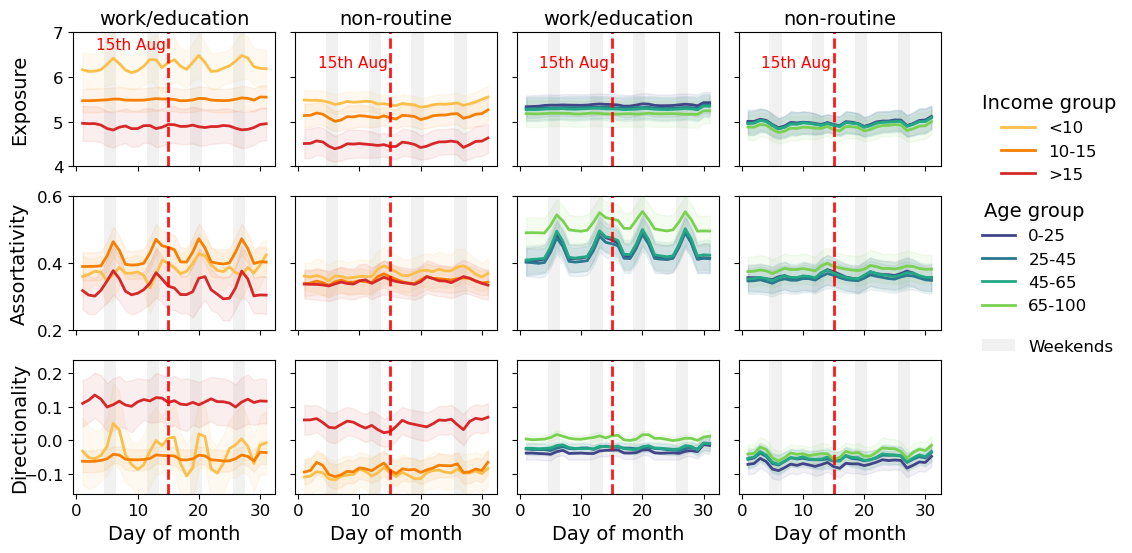

In [155]:
weekend_days = sorted(df_inc_routine.loc[df_inc_routine['is_weekend'], 'day'].unique())

palette_income = {'<10':'#FCBF49', '10-15':'#F77F00', '>15':'#D62828'}

viridis_colors = sns.color_palette('viridis', n_colors=len(age_groups))
palette_age = {ag: col for ag, col in zip(age_groups, viridis_colors)}

row_axes = {
    'E_T':   {'ylim': (4, 7),       'yticks': [4,5,6,7],      'ylabel':'Exposure'},
    'rho_T': {'ylim': (0.2, 0.6),   'yticks': [0.2,0.4,0.6],  'ylabel':'Assortativity'},
    'R_T':   {'ylim': (-0.16, 0.24),'yticks': [-0.1,0,0.1,0.2],'ylabel':'Directionality'},
}

col_titles = [
    'work/education',
    'non-routine',
    'work/education',
    'non-routine'
]

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(11, 6), sharex=True, sharey='row')

panels = [
    (df_inc_routine, income_groups, palette_income, 'income'),
    (df_inc_nonrout, income_groups, palette_income, 'income'),
    (df_age_routine, age_groups,    palette_age,    'age'),
    (df_age_nonrout, age_groups,    palette_age,    'age'),
]



for r, m in enumerate(metrics):
    for c, (df_panel, groups, palette, ptype) in enumerate(panels):
        ax = axes[r, c]

        # weekend shading
        for wd in weekend_days:
            ax.axvspan(wd - 0.5, wd + 0.5, color='lightgrey', alpha=.3, lw=0)

        ax.set_ylim(*row_axes[m]['ylim'])
        ax.set_yticks(row_axes[m]['yticks'])

        for g in groups:
            sub   = df_panel[df_panel['group'] == g]
            stats = day_stats_weighted(sub, m, smooth_window=2)

            ax.plot(stats['day'], stats['mean'], lw=2, color=palette[g], label=str(g))
            ax.fill_between(stats['day'],
                            stats['mean'] - stats['se'],
                            stats['mean'] + stats['se'],
                            alpha=.08, color=palette[g])

        # 15 Aug marker
        if month_of_analysis == 8:
            ax.axvline(x=15.0, color='red', linestyle='--', linewidth=2, alpha=0.9)

            if (r == 0) and (c == 0):
                ymin, ymax = ax.get_ylim()
                ax.text(14.6, ymax - 0.1,
                        '15th Aug', color='red', fontsize=11,
                        ha='right', va='top')
            elif (r == 0):
                ymin, ymax = ax.get_ylim()
                ax.text(14.6, ymax - 0.5,
                            '15th Aug', color='red', fontsize=11,
                            ha='right', va='top')


        if r == 0:
            ax.set_title(col_titles[c], fontsize=14)
        if c == 0:
            ax.set_ylabel(row_axes[m]['ylabel'], fontsize=14)
        if r == 2:
            ax.set_xlabel('Day of month', fontsize=14)

        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)


h_inc, l_inc = axes[0,0].get_legend_handles_labels()
h_age, l_age = axes[0,2].get_legend_handles_labels()

weekend_patch = mpatches.Patch(facecolor='lightgrey', alpha=.3, edgecolor='none', label='Weekends')

fig.legend(h_inc, l_inc,
           title='Income group', frameon=False,
           loc='upper left', bbox_to_anchor=(0.91, 0.83),
           fontsize=12, title_fontsize=14)

fig.legend(h_age, l_age,
           title='Age group', frameon=False,
           loc='upper left', bbox_to_anchor=(0.91, 0.65),
           fontsize=12, title_fontsize=14)

fig.legend([weekend_patch], ['Weekends'],
           title='', frameon=False,
           loc='upper left', bbox_to_anchor=(0.91, 0.42),
           fontsize=12, title_fontsize=14)

for r in range(len(metrics)):
    axes[r, 0].yaxis.set_label_coords(-0.22, 0.5)
    
plt.tight_layout(rect=[0.03, 0.03, 0.9, 0.97])
plt.savefig(f'daily_metrics_income_age_routine_vs_nonroutine_{year_of_analysis}_{month_of_analysis}.svg',
            dpi=300, bbox_inches='tight')
plt.show()